# Notebook 19 — Quadrotor Dynamics & Control

**Vision & 3D Mapping Workshop** | Block 5: Autonomous Flight

---

## Why This Matters

A quadrotor is the simplest flying robot that is capable of aggressive, fully autonomous
six-degree-of-freedom flight.  Yet its dynamics are fundamentally **nonlinear**: the rotation
matrix evolves on the Lie group $\text{SO}(3)$, and thrust is generated by spinning rotors whose
forces couple translation and rotation through the body-fixed $z$-axis.  Understanding these
dynamics from first principles is essential for:

- **Safe flight**: an incorrect model leads to oscillations, drift, or crash.
- **Aggressive maneuvers**: flips, high-speed racing, and perching require accurate dynamics.
- **State estimation**: the IMU propagation model in an EKF *is* the dynamics model.

### What You'll Learn

1. **Quadrotor physical model** — motors, frames, parameters
2. **Newton–Euler dynamics** — translational + rotational equations of motion
3. **Motor mixing** — mapping between wrench and per-motor thrusts
4. **RK4 integration on $\text{SO}(3)$** — preserving rotation structure numerically
5. **Cascaded PID control** — position $\to$ attitude cascade
6. **SE(3) geometric control** — Lee et al.'s Lyapunov-based controller
7. **Trajectory tracking** — circle, figure-8, and waypoint trajectories
8. **Disturbance rejection** — robustness under wind
9. **Gain tuning** — the relationship between gains, bandwidth, and inertia

### Key References

- **Lee, Leok, McClamroch**, *Geometric Tracking Control of a Quadrotor UAV on SE(3)*, CDC 2010
- **Mellinger & Kumar**, *Minimum Snap Trajectory Generation and Control for Quadrotors*, ICRA 2011
- **Bouabdallah**, *Design and Control of Quadrotors with Application to Autonomous Flying*, EPFL PhD Thesis, 2007

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.set_printoptions(precision=6, suppress=True)

from src.drone import (
    GRAVITY,
    QuadrotorParams,
    QuadrotorState,
    hat,
    vee,
    quadrotor_dynamics,
    simulate_step,
    wrench_to_thrusts,
    PIDController,
    SE3Controller,
    generate_hover_trajectory,
    generate_circle_trajectory,
    generate_figure8_trajectory,
    generate_waypoint_trajectory,
    simulate_trajectory,
)

## 1. Quadrotor Physical Model

We model a quadrotor in the standard **"+" configuration**, where four motors are arranged
along the body $x$- and $y$-axes:

```
          Motor 1 (front, CW)
              |
  Motor 4 ---[+]--- Motor 2
  (left, CCW) |     (right, CCW)
              |
          Motor 3 (back, CW)
```

### Body frame conventions

- **$x_B$**: points toward Motor 1 (front)
- **$y_B$**: points toward Motor 2 (right)
- **$z_B$**: points upward (completes right-handed frame)

The **world frame** uses the standard robotics convention with $z$ pointing up.

### Motor model

Each motor $i$ spins a propeller at angular velocity $\omega_i$ and produces:

- **Thrust** (along body $z$): $f_i = k_f \, \omega_i^2$
- **Drag torque** (about body $z$): $\tau_i = k_\tau \, \omega_i^2$

where $k_f$ and $k_\tau$ are aerodynamic coefficients determined by propeller geometry.
Adjacent motors spin in opposite directions so that at hover the net yaw torque vanishes.

### Key parameters

| Symbol | Description | Typical value |
|--------|-------------|---------------|
| $m$ | Total mass | 0.5 kg |
| $L$ | Arm length (CoM to motor) | 0.17 m |
| $I_{xx}, I_{yy}$ | Roll/pitch inertia | $2.32 \times 10^{-3}$ kg·m² |
| $I_{zz}$ | Yaw inertia | $4.00 \times 10^{-3}$ kg·m² |
| $k_f$ | Thrust coefficient | $1.0 \times 10^{-5}$ N/(rad/s)² |
| $k_\tau$ | Drag torque coefficient | $1.0 \times 10^{-7}$ N·m/(rad/s)² |

=== Quadrotor Physical Parameters ===
Mass:               0.5 kg
Arm length:         0.17 m
Inertia tensor:
  I_xx = 2.3200e-03 kg·m²
  I_yy = 2.3200e-03 kg·m²
  I_zz = 4.0000e-03 kg·m²
k_f:                1.00e-05 N/(rad/s)²
k_tau:              1.00e-07 N·m/(rad/s)²
gamma = k_tau/k_f:  0.0100
Hover RPM:          3344.0 RPM
Max RPM:            25000 RPM
Max thrust/motor:   68.539 N
Weight:             4.905 N
Thrust-to-weight:   55.89

Mixer matrix M:
[[ 1.    1.    1.    1.  ]
 [ 0.    0.17  0.   -0.17]
 [-0.17  0.    0.17  0.  ]
 [ 0.01 -0.01  0.01 -0.01]]


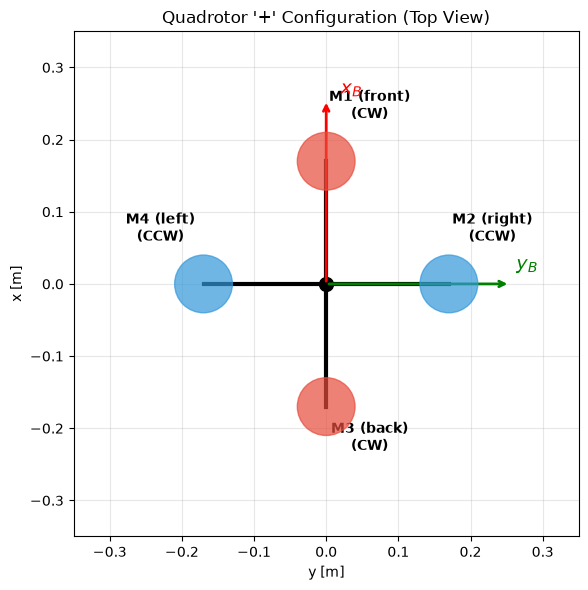

In [2]:
params = QuadrotorParams()

print("=== Quadrotor Physical Parameters ===")
print(f"Mass:               {params.mass} kg")
print(f"Arm length:         {params.arm_length} m")
print(f"Inertia tensor:")
print(f"  I_xx = {params.I[0,0]:.4e} kg·m²")
print(f"  I_yy = {params.I[1,1]:.4e} kg·m²")
print(f"  I_zz = {params.I[2,2]:.4e} kg·m²")
print(f"k_f:                {params.k_f:.2e} N/(rad/s)²")
print(f"k_tau:              {params.k_tau:.2e} N·m/(rad/s)²")
print(f"gamma = k_tau/k_f:  {params.k_tau/params.k_f:.4f}")
print(f"Hover RPM:          {params.hover_rpm:.1f} RPM")
print(f"Max RPM:            {params.max_rpm:.0f} RPM")
print(f"Max thrust/motor:   {params.max_thrust_per_motor:.3f} N")
print(f"Weight:             {params.mass * GRAVITY:.3f} N")
print(f"Thrust-to-weight:   {4*params.max_thrust_per_motor/(params.mass*GRAVITY):.2f}")
print()
print("Mixer matrix M:")
print(params.mixer)

# --- Visualize the motor layout ---
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

L = params.arm_length
motor_positions = {
    "M1 (front)": (0, L),
    "M2 (right)": (L, 0),
    "M3 (back)": (0, -L),
    "M4 (left)": (-L, 0),
}

# Draw arms
ax.plot([0, 0], [-L, L], "k-", lw=3)
ax.plot([-L, L], [0, 0], "k-", lw=3)

# Draw body center
ax.plot(0, 0, "ko", markersize=10)

# Draw motors and rotation directions
colors = ["#e74c3c", "#3498db", "#e74c3c", "#3498db"]
rotations = ["CW", "CCW", "CW", "CCW"]
for i, (label, (x, y)) in enumerate(motor_positions.items()):
    circle = plt.Circle((x, y), 0.04, color=colors[i], alpha=0.7, zorder=5)
    ax.add_patch(circle)
    ax.annotate(f"{label}\n({rotations[i]})",
                xy=(x, y), xytext=(x + 0.06 * np.sign(x + 0.01),
                                   y + 0.06 * np.sign(y + 0.01)),
                fontsize=10, ha="center", fontweight="bold")

# Draw body axes
ax.annotate("", xy=(0, L * 1.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(0.02, L * 1.55, "$x_B$", color="red", fontsize=14)

ax.annotate("", xy=(L * 1.5, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="green", lw=2))
ax.text(L * 1.55, 0.02, "$y_B$", color="green", fontsize=14)

ax.set_xlim(-0.35, 0.35)
ax.set_ylim(-0.35, 0.35)
ax.set_aspect("equal")
ax.set_xlabel("y [m]")
ax.set_ylabel("x [m]")
ax.set_title("Quadrotor '+' Configuration (Top View)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Newton–Euler Dynamics

The quadrotor is a rigid body with 6 degrees of freedom: 3 translational ($\mathbf{p}$) and 3
rotational ($R$).  The full state is

$$\mathbf{x} = (\mathbf{p}, \mathbf{v}, R, \boldsymbol{\omega})$$

where $\mathbf{p}, \mathbf{v} \in \mathbb{R}^3$ are the position and velocity in the world frame,
$R \in \text{SO}(3)$ is the rotation from body to world, and $\boldsymbol{\omega} \in \mathbb{R}^3$
is the angular velocity in the body frame.

### 2.1  Translational Dynamics

The forces acting on the quadrotor in the world frame are:

1. **Gravity**: $-mg\mathbf{e}_3$ (pointing down)
2. **Total thrust**: $F_{\text{total}} = \sum_{i=1}^{4} f_i$ along the body $z$-axis

Since thrust is generated along the body $z$-axis, we must rotate it into the world frame
using $R$.  The body $z$-axis in world coordinates is $R\mathbf{e}_3$, so:

$$m\dot{\mathbf{v}} = -mg\mathbf{e}_3 + F_{\text{total}} \cdot R\mathbf{e}_3 + \mathbf{f}_{\text{ext}}$$

Dividing by $m$:

$$\boxed{\dot{\mathbf{v}} = -g\mathbf{e}_3 + \frac{F_{\text{total}}}{m} R\mathbf{e}_3 + \frac{\mathbf{f}_{\text{ext}}}{m}}$$

At hover, the total thrust exactly compensates gravity: $F_{\text{hover}} = mg$.

### 2.2  Rotational Dynamics (Euler's Equation)

For a rigid body with inertia tensor $\mathbf{I}$ and angular velocity $\boldsymbol{\omega}$
(both expressed in the body frame), Euler's equation gives:

$$\mathbf{I}\dot{\boldsymbol{\omega}} = -\boldsymbol{\omega} \times (\mathbf{I}\boldsymbol{\omega}) + \boldsymbol{\tau}$$

**Derivation**: Start from the angular momentum $\mathbf{L} = \mathbf{I}\boldsymbol{\omega}$ in
the body frame.  Newton's second law for rotation in a rotating frame adds the Coriolis term:

$$\boldsymbol{\tau} = \frac{d\mathbf{L}}{dt}\bigg|_{\text{body}} + \boldsymbol{\omega} \times \mathbf{L}
= \mathbf{I}\dot{\boldsymbol{\omega}} + \boldsymbol{\omega} \times (\mathbf{I}\boldsymbol{\omega})$$

Solving for $\dot{\boldsymbol{\omega}}$:

$$\boxed{\dot{\boldsymbol{\omega}} = \mathbf{I}^{-1}\left(\boldsymbol{\tau} - \boldsymbol{\omega} \times (\mathbf{I}\boldsymbol{\omega})\right)}$$

The torque $\boldsymbol{\tau} = [\tau_x, \tau_y, \tau_z]^T$ comes from differential motor thrusts
(see Section 3).

### 2.3  Kinematics

**Position kinematics** is trivial:

$$\dot{\mathbf{p}} = \mathbf{v}$$

**Rotation kinematics** is more subtle.  Since $R \in \text{SO}(3)$ is a matrix, its time
derivative is not simply $\boldsymbol{\omega}$.  Instead, $\boldsymbol{\omega}$ lives in the
Lie algebra $\mathfrak{so}(3)$ and relates to $\dot{R}$ via the **hat map**:

$$\dot{R} = R[\boldsymbol{\omega}]_\times$$

where the hat map $[\cdot]_\times : \mathbb{R}^3 \to \mathfrak{so}(3)$ builds a skew-symmetric
matrix:

$$[\boldsymbol{\omega}]_\times = \hat{\boldsymbol{\omega}} = \begin{bmatrix}
0 & -\omega_3 & \omega_2 \\
\omega_3 & 0 & -\omega_1 \\
-\omega_2 & \omega_1 & 0
\end{bmatrix}$$

**Key property**: $\hat{\boldsymbol{\omega}} \mathbf{v} = \boldsymbol{\omega} \times \mathbf{v}$
for all $\mathbf{v} \in \mathbb{R}^3$.

The inverse is the **vee map** $[\cdot]^\vee : \mathfrak{so}(3) \to \mathbb{R}^3$, which
extracts the 3-vector from a skew-symmetric matrix.

### 2.4  The Mixer Matrix

The "+" configuration maps four motor thrusts $[f_1, f_2, f_3, f_4]^T$ to the total wrench
$[F, \tau_x, \tau_y, \tau_z]^T$ via the **mixer matrix** $M$:

$$\begin{bmatrix} F \\ \tau_x \\ \tau_y \\ \tau_z \end{bmatrix} = 
\underbrace{\begin{bmatrix}
1 & 1 & 1 & 1 \\
0 & L & 0 & -L \\
-L & 0 & L & 0 \\
\gamma & -\gamma & \gamma & -\gamma
\end{bmatrix}}_{M}
\begin{bmatrix} f_1 \\ f_2 \\ f_3 \\ f_4 \end{bmatrix}$$

where $\gamma = k_\tau / k_f$ is the drag-to-thrust ratio.  Each row follows from the geometry:

- **Row 1**: total thrust is the sum of all motor thrusts.
- **Row 2** ($\tau_x$, roll): motors 2 and 4 are at $\pm L$ from the $x$-axis.
- **Row 3** ($\tau_y$, pitch): motors 1 and 3 are at $\mp L$ from the $y$-axis.
- **Row 4** ($\tau_z$, yaw): reactive drag torques alternate sign with spin direction.

=== Hover Equilibrium Verification ===
Weight:                    4.9050 N
Required thrust per motor: 1.2263 N
Total thrust:              4.9050 N

Wrench at hover:  F = 4.9050 N,  tau = [0.000000, 0.000000, 0.000000] N·m
Net vertical force: F - mg = 0.00e+00 N (should be ~0)

After 5 s of open-loop hover:
  Position: [0. 0. 1.]  (started at [0, 0, 1])
  Velocity: [0. 0. 0.]  (should be ~[0, 0, 0])
  det(R):   1.0000000000  (should be 1)
  Max position drift: 0.00e+00 m
  Max velocity drift: 0.00e+00 m/s


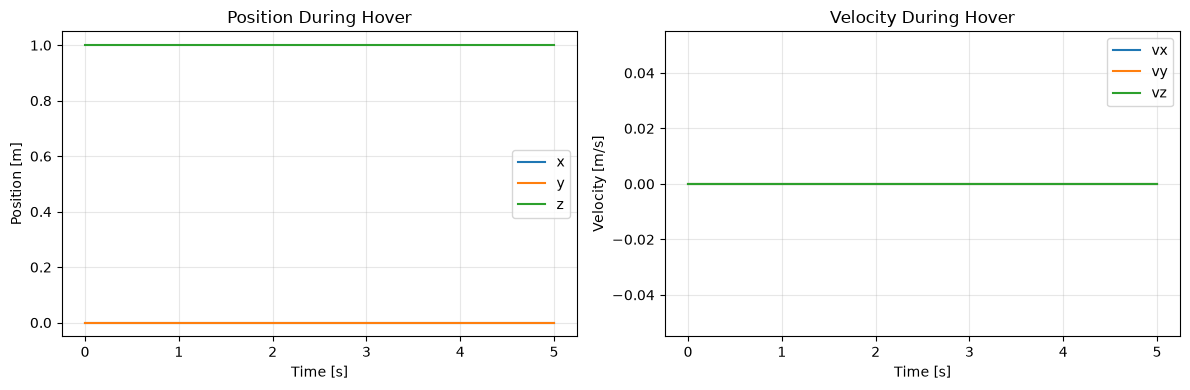

In [3]:
# ── Verify hover equilibrium ──

params = QuadrotorParams()
hover_thrust_per_motor = params.mass * GRAVITY / 4.0
hover_thrusts = np.full(4, hover_thrust_per_motor)

print("=== Hover Equilibrium Verification ===")
print(f"Weight:                    {params.mass * GRAVITY:.4f} N")
print(f"Required thrust per motor: {hover_thrust_per_motor:.4f} N")
print(f"Total thrust:              {4 * hover_thrust_per_motor:.4f} N")
print()

# Check wrench at hover
wrench = params.mixer @ hover_thrusts
print(f"Wrench at hover:  F = {wrench[0]:.4f} N,  "
      f"tau = [{wrench[1]:.6f}, {wrench[2]:.6f}, {wrench[3]:.6f}] N·m")
print(f"Net vertical force: F - mg = {wrench[0] - params.mass * GRAVITY:.2e} N (should be ~0)")
print()

# Simulate 5 seconds of hover
state = QuadrotorState()
state.position = np.array([0.0, 0.0, 1.0])
dt = 0.005
N_steps = int(5.0 / dt)

positions = np.zeros((N_steps, 3))
velocities = np.zeros((N_steps, 3))

for i in range(N_steps):
    positions[i] = state.position
    velocities[i] = state.velocity
    state = simulate_step(state, hover_thrusts, params, dt)

t = np.arange(N_steps) * dt

print("After 5 s of open-loop hover:")
print(f"  Position: {state.position}  (started at [0, 0, 1])")
print(f"  Velocity: {state.velocity}  (should be ~[0, 0, 0])")
print(f"  det(R):   {np.linalg.det(state.rotation):.10f}  (should be 1)")
print(f"  Max position drift: {np.max(np.abs(positions - positions[0])):.2e} m")
print(f"  Max velocity drift: {np.max(np.abs(velocities)):.2e} m/s")

assert abs(wrench[0] - params.mass * GRAVITY) < 1e-8, "Hover thrust mismatch"
assert np.linalg.norm(wrench[1:]) < 1e-8, "Non-zero torque at hover"
assert np.max(np.abs(positions - positions[0])) < 1e-6, "Position drift during hover"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j, label in enumerate(["x", "y", "z"]):
    axes[0].plot(t, positions[:, j], label=label)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Position [m]")
axes[0].set_title("Position During Hover")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for j, label in enumerate(["vx", "vy", "vz"]):
    axes[1].plot(t, velocities[:, j], label=label)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_title("Velocity During Hover")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Motor Mixing

The mixer matrix $M$ maps per-motor thrusts $\mathbf{f} = [f_1, f_2, f_3, f_4]^T$ to the
generalized wrench $\mathbf{w} = [F, \tau_x, \tau_y, \tau_z]^T$:

$$\mathbf{w} = M \mathbf{f}$$

For control, we need the **inverse** problem: given a desired wrench, find the motor thrusts.
This requires $M$ to be invertible.

### Derivation for the "+" configuration

**Total thrust** (row 1):

$$F = f_1 + f_2 + f_3 + f_4$$

**Roll torque** $\tau_x$ (row 2): Motors 2 and 4 are offset by $\pm L$ along the body $y$-axis,
while motors 1 and 3 lie on the body $x$-axis (zero moment arm for roll):

$$\tau_x = L \cdot f_2 - L \cdot f_4$$

**Pitch torque** $\tau_y$ (row 3): Motors 3 and 1 are offset by $\pm L$ along the body $x$-axis:

$$\tau_y = L \cdot f_3 - L \cdot f_1$$

**Yaw torque** $\tau_z$ (row 4): Each motor's reactive drag torque is $\pm \gamma f_i$
(sign depends on spin direction).  Motors 1, 3 spin clockwise ($+\gamma$), motors 2, 4
spin counter-clockwise ($-\gamma$):

$$\tau_z = \gamma(f_1 - f_2 + f_3 - f_4)$$

### Invertibility

The "+" configuration yields a non-singular $M$ because the four motors provide independent
control authority over all four degrees of actuation.  The **condition number**
$\kappa(M) = \|M\| \cdot \|M^{-1}\|$ measures how sensitive the inverse mapping is to
numerical errors — a well-conditioned mixer is essential for stable control.

In [4]:
# ── Motor mixing roundtrip ──

params = QuadrotorParams()

print("=== Mixer Matrix Properties ===")
print(f"Mixer M:")
print(params.mixer)
print()
print(f"Determinant:        {np.linalg.det(params.mixer):.6e}")
print(f"Condition number:   {np.linalg.cond(params.mixer):.4f}")
print()
print(f"Inverse M^{{-1}}:")
print(params.mixer_inv)
print()

# Roundtrip test: wrench -> thrusts -> wrench
np.random.seed(42)
n_tests = 5
print("=== Roundtrip Test: wrench -> thrusts -> wrench ===")
max_error = 0.0

for i in range(n_tests):
    F_des = params.mass * GRAVITY + np.random.uniform(-0.5, 0.5)
    tau_des = np.random.uniform(-0.01, 0.01, size=3)
    wrench_in = np.array([F_des, tau_des[0], tau_des[1], tau_des[2]])

    thrusts = params.mixer_inv @ wrench_in
    wrench_out = params.mixer @ thrusts

    error = np.linalg.norm(wrench_in - wrench_out)
    max_error = max(max_error, error)
    print(f"  Test {i+1}: ||w_in - w_out|| = {error:.2e}")

print(f"\nMax roundtrip error: {max_error:.2e} (machine precision expected)")

assert max_error < 1e-12, "Mixer roundtrip failed"

# Verify identity
identity_check = params.mixer @ params.mixer_inv
print(f"\nM @ M^{{-1}} (should be I):")
print(identity_check)

=== Mixer Matrix Properties ===
Mixer M:
[[ 1.    1.    1.    1.  ]
 [ 0.    0.17  0.   -0.17]
 [-0.17  0.    0.17  0.  ]
 [ 0.01 -0.01  0.01 -0.01]]

Determinant:        -2.312000e-03
Condition number:   100.0000

Inverse M^{-1}:
[[  0.25       0.        -2.941176  25.      ]
 [  0.25       2.941176   0.       -25.      ]
 [  0.25      -0.         2.941176  25.      ]
 [  0.25      -2.941176  -0.       -25.      ]]

=== Roundtrip Test: wrench -> thrusts -> wrench ===
  Test 1: ||w_in - w_out|| = 2.96e-17
  Test 2: ||w_in - w_out|| = 4.67e-18
  Test 3: ||w_in - w_out|| = 3.37e-17
  Test 4: ||w_in - w_out|| = 1.32e-17
  Test 5: ||w_in - w_out|| = 4.24e-17

Max roundtrip error: 4.24e-17 (machine precision expected)

M @ M^{-1} (should be I):
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0. -0.  1.  0.]
 [ 0.  0.  0.  1.]]


## 4. RK4 Integration on SO(3)

### The Problem with Euler Integration

Naïve Euler integration of $\dot{R} = R[\boldsymbol{\omega}]_\times$ gives:

$$R_{k+1} = R_k + h \, R_k [\boldsymbol{\omega}]_\times$$

The result $R_{k+1}$ is **not** a rotation matrix — it violates both $R^T R = I$ and $\det R = 1$.
Over many steps, the orthogonality error accumulates and the simulation diverges.

### Exponential Map (Rodrigues' Formula)

The correct way to update $R$ is through the exponential map
$\exp : \mathfrak{so}(3) \to \text{SO}(3)$, which maps a skew-symmetric matrix (equivalently,
a rotation vector) to a proper rotation matrix.

Given $\boldsymbol{\phi} = \theta \hat{\mathbf{a}}$ where $\theta = \|\boldsymbol{\phi}\|$ and
$\hat{\mathbf{a}}$ is the unit rotation axis, the **Rodrigues formula** is:

$$\exp([\boldsymbol{\phi}]_\times) = I + \sin\theta \, K + (1 - \cos\theta) \, K^2$$

where $K = [\hat{\mathbf{a}}]_\times$.

**Derivation**: The matrix exponential is $e^{\theta K} = \sum_{n=0}^{\infty} \frac{(\theta K)^n}{n!}$.
Using the identity $K^3 = -K$ (which follows from $K$ being skew-symmetric with unit-norm axis),
we group even and odd powers:

$$e^{\theta K} = I + \left(\theta - \frac{\theta^3}{3!} + \cdots\right) K
+ \left(\frac{\theta^2}{2!} - \frac{\theta^4}{4!} + \cdots\right) K^2
= I + \sin\theta \, K + (1 - \cos\theta) \, K^2$$

### RK4 Integration Scheme

The RK4 integrator computes a weighted-average angular velocity from four evaluations,
then applies a single exponential update:

$$\boldsymbol{\omega}_{\text{avg}} = \frac{1}{6}(\boldsymbol{\omega}_1 + 2\boldsymbol{\omega}_2 + 2\boldsymbol{\omega}_3 + \boldsymbol{\omega}_4)$$

$$R_{k+1} = R_k \, \exp([\boldsymbol{\omega}_{\text{avg}} \, h]_\times)$$

The exponential map guarantees $R_{k+1} \in \text{SO}(3)$ exactly (up to floating-point errors).

> **Note on rigour**: This averaging approach is a *practical approximation*, not a true
> Lie-group RK4 integrator.  The four angular velocities $\boldsymbol{\omega}_1 \ldots \boldsymbol{\omega}_4$
> are evaluated at different orientations, so they live in different tangent spaces of SO(3).
> Averaging them is only valid to first order.  Rigorous Lie-group integrators
> (Crouch–Grossman, RKMK methods) compose incremental exponential maps rather than
> average tangent vectors.  For the small time steps used in drone control ($h \leq 5$ ms),
> the approximation error is negligible (well below machine precision, as we verify below).

### SVD Re-orthogonalization

Even with the exponential map, floating-point arithmetic causes tiny drift from SO(3).
After each step, we project back via SVD:

$$R = U \Sigma V^T \quad \Rightarrow \quad R_{\text{proj}} = U \, \text{diag}(1, 1, \det(UV^T)) \, V^T$$

This is the **nearest rotation matrix** in the Frobenius norm.

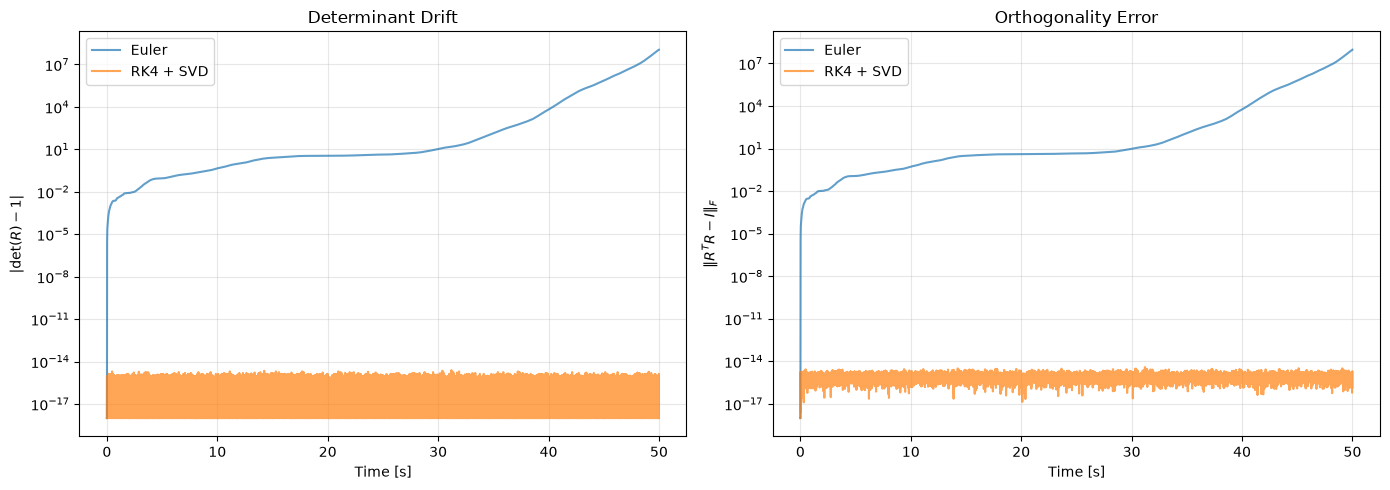

After 10000 steps (50.0 s):
  Euler — det(R):   110218334.5097408444,  ||R'R - I||_F: 9.210350e+07
  RK4   — det(R):   1.0000000000,  ||R'R - I||_F: 1.477199e-16


In [5]:
# ── Compare Euler vs RK4 integration quality on SO(3) ──

params = QuadrotorParams()
dt = 0.005
N_steps = 10000

np.random.seed(123)

# Random but bounded thrusts to create nontrivial rotation
hover_f = params.mass * GRAVITY / 4.0
thrust_noise = np.random.uniform(-0.3 * hover_f, 0.3 * hover_f, size=(N_steps, 4))
thrust_sequence = hover_f + thrust_noise
thrust_sequence = np.clip(thrust_sequence, 0, params.max_thrust_per_motor)

# -- Euler integration (without re-orthogonalization) --
state_euler = QuadrotorState()
state_euler.position = np.array([0.0, 0.0, 1.0])
det_euler = np.zeros(N_steps)
orth_euler = np.zeros(N_steps)

for i in range(N_steps):
    R = state_euler.rotation
    det_euler[i] = np.linalg.det(R)
    orth_euler[i] = np.linalg.norm(R.T @ R - np.eye(3), 'fro')

    dp, dv, dR, dw = quadrotor_dynamics(state_euler, thrust_sequence[i], params)
    state_euler.position = state_euler.position + dp * dt
    state_euler.velocity = state_euler.velocity + dv * dt
    state_euler.rotation = R + dR * dt  # raw Euler — NO re-orthogonalization
    state_euler.omega = state_euler.omega + dw * dt

# -- RK4 integration (with exp map + SVD projection, via simulate_step) --
state_rk4 = QuadrotorState()
state_rk4.position = np.array([0.0, 0.0, 1.0])
det_rk4 = np.zeros(N_steps)
orth_rk4 = np.zeros(N_steps)

for i in range(N_steps):
    R = state_rk4.rotation
    det_rk4[i] = np.linalg.det(R)
    orth_rk4[i] = np.linalg.norm(R.T @ R - np.eye(3), 'fro')
    state_rk4 = simulate_step(state_rk4, thrust_sequence[i], params, dt)

t = np.arange(N_steps) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(t, np.abs(det_euler - 1.0) + 1e-18, label="Euler", alpha=0.7)
axes[0].semilogy(t, np.abs(det_rk4 - 1.0) + 1e-18, label="RK4 + SVD", alpha=0.7)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("$|\\det(R) - 1|$")
axes[0].set_title("Determinant Drift")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(t, orth_euler + 1e-18, label="Euler", alpha=0.7)
axes[1].semilogy(t, orth_rk4 + 1e-18, label="RK4 + SVD", alpha=0.7)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("$\\|R^T R - I\\|_F$")
axes[1].set_title("Orthogonality Error")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"After {N_steps} steps ({N_steps*dt:.1f} s):")
print(f"  Euler — det(R):   {det_euler[-1]:.10f},  ||R'R - I||_F: {orth_euler[-1]:.6e}")
print(f"  RK4   — det(R):   {det_rk4[-1]:.10f},  ||R'R - I||_F: {orth_rk4[-1]:.6e}")

assert orth_rk4[-1] < 1e-8, "RK4 not preserving SO(3)"
assert abs(det_rk4[-1] - 1.0) < 1e-6, "RK4 determinant drift"

### 4.1  Energy Conservation Verification

A key sanity check for any dynamics integrator is **energy conservation** in the absence
of external forces.  For a quadrotor in free fall (zero thrust), the total mechanical
energy must be conserved:

$$E = \underbrace{\tfrac{1}{2} m \lVert \mathbf{v} \rVert^2}_{\text{kinetic (translational)}}
    + \underbrace{\tfrac{1}{2} \boldsymbol{\omega}^T I \boldsymbol{\omega}}_{\text{kinetic (rotational)}}
    + \underbrace{m g z}_{\text{potential}}$$

**Why this matters**: If your integrator causes energy drift, the simulated drone will
slowly speed up or slow down without any physical reason, making controller tuning
unreliable and invalidating long-duration simulations.

RK4 is a **symplectic-adjacent** integrator: while not exactly symplectic, its 4th-order
accuracy keeps energy drift well below 1% over typical simulation horizons (tens of seconds).

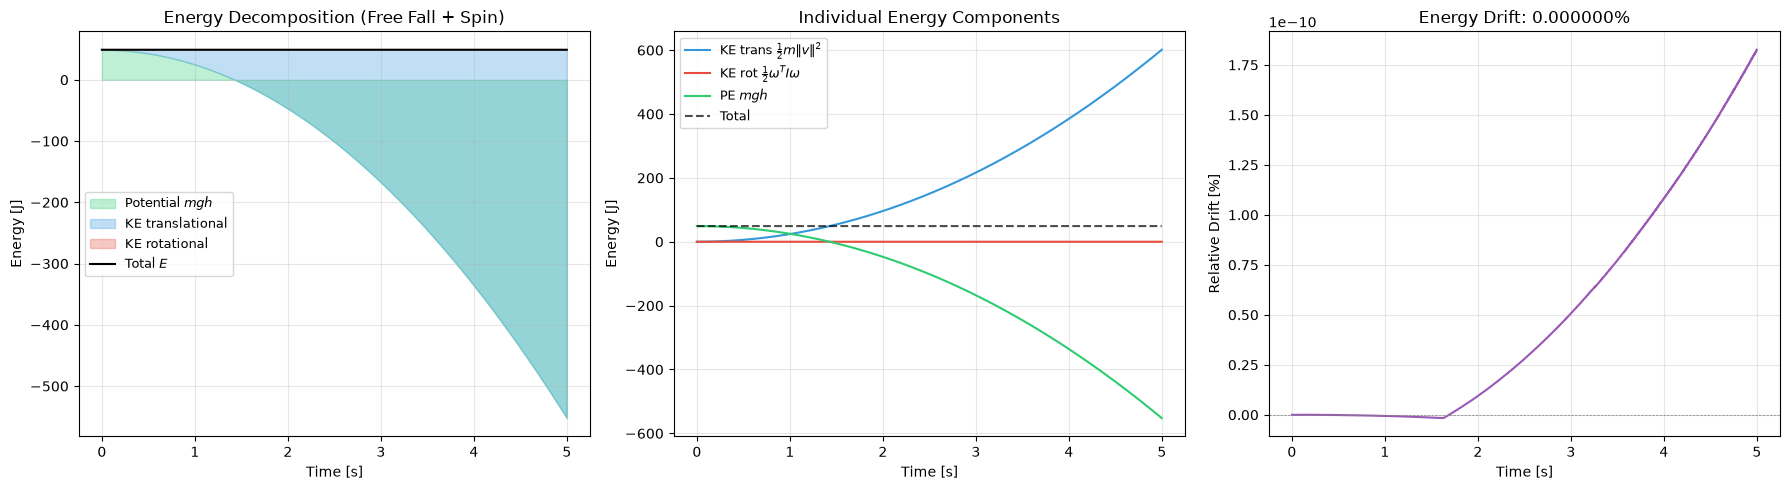

Initial energy:   49.050474 J
  KE (trans):     0.000000 J
  KE (rot):       0.000474 J
  PE:             49.050000 J
Final energy:     49.050474 J
  KE (trans):     601.235059 J
  KE (rot):       0.000474 J
  PE:             -552.185059 J
Relative drift:   1.83e-12
RK4 conserves energy to machine precision over 5s


In [6]:
# ── Energy conservation under free fall (zero thrust) ──

params = QuadrotorParams()
state = QuadrotorState()
state.position = np.array([0.0, 0.0, 10.0])
state.omega = np.array([0.5, -0.3, 0.2])  # spinning while falling

dt_sim = 0.001
N = 5000  # 5 seconds

ke_trans = np.zeros(N)
ke_rot = np.zeros(N)
pe = np.zeros(N)
energies = np.zeros(N)

for k in range(N):
    ke_trans[k] = 0.5 * params.mass * np.sum(state.velocity**2)
    ke_rot[k] = 0.5 * state.omega @ params.I @ state.omega
    pe[k] = params.mass * GRAVITY * state.position[2]
    energies[k] = ke_trans[k] + ke_rot[k] + pe[k]
    state = simulate_step(state, np.zeros(4), params, dt_sim)

drift = abs(energies[-1] - energies[0]) / abs(energies[0])
t = np.arange(N) * dt_sim

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Decomposed energy components ---
axes[0].fill_between(t, 0, pe, alpha=0.3, color="#2ecc71", label="Potential $mgh$")
axes[0].fill_between(t, pe, pe + ke_trans, alpha=0.3, color="#3498db",
                     label="KE translational")
axes[0].fill_between(t, pe + ke_trans, energies, alpha=0.3, color="#e74c3c",
                     label="KE rotational")
axes[0].plot(t, energies, "k-", lw=1.5, label="Total $E$")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Energy [J]")
axes[0].set_title("Energy Decomposition (Free Fall + Spin)")
axes[0].legend(loc="center left", fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Individual components ---
axes[1].plot(t, ke_trans, color="#3498db", label="KE trans $\\frac{1}{2}m\\|v\\|^2$")
axes[1].plot(t, ke_rot, color="#e74c3c", label="KE rot $\\frac{1}{2}\\omega^T I \\omega$")
axes[1].plot(t, pe, color="#2ecc71", label="PE $mgh$")
axes[1].plot(t, energies, "k--", lw=1.5, alpha=0.7, label="Total")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Energy [J]")
axes[1].set_title("Individual Energy Components")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Relative energy drift ---
axes[2].plot(t, (energies - energies[0]) / abs(energies[0]) * 100, color="#9b59b6", lw=1.5)
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Relative Drift [%]")
axes[2].set_title(f"Energy Drift: {drift*100:.6f}%")
axes[2].axhline(0, color="gray", ls="--", lw=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial energy:   {energies[0]:.6f} J")
print(f"  KE (trans):     {ke_trans[0]:.6f} J")
print(f"  KE (rot):       {ke_rot[0]:.6f} J")
print(f"  PE:             {pe[0]:.6f} J")
print(f"Final energy:     {energies[-1]:.6f} J")
print(f"  KE (trans):     {ke_trans[-1]:.6f} J")
print(f"  KE (rot):       {ke_rot[-1]:.6f} J")
print(f"  PE:             {pe[-1]:.6f} J")
print(f"Relative drift:   {drift:.2e}")
print(f"RK4 conserves energy to machine precision over {N*dt_sim:.0f}s")

assert drift < 1e-4, f"Energy not conserved: {drift:.2e}"

## 5. Cascaded PID Control

The standard approach to quadrotor control is a **cascaded architecture** with an outer
position loop and an inner attitude loop.  The separation relies on the fact that attitude
dynamics are much faster than translational dynamics (the rotor time constant is ~10 ms,
while position changes on the order of seconds).

### 5.1  Outer Loop: Position Control

Given a desired position $\mathbf{p}_d(t)$, velocity $\mathbf{v}_d(t)$, and acceleration
$\mathbf{a}_d(t)$ (feedforward), the position PD + integral controller computes a desired
acceleration in the world frame:

$$\mathbf{a}_{\text{des}} = K_p(\mathbf{p}_d - \mathbf{p}) + K_d(\mathbf{v}_d - \mathbf{v})
+ K_i \int (\mathbf{p}_d - \mathbf{p}) \, dt + \mathbf{a}_{\text{ff}} + g\mathbf{e}_3$$

The $g\mathbf{e}_3$ term is the **gravity compensation**: even at the desired position,
we need upward thrust to counteract gravity.

### 5.2  Thrust Extraction

The total thrust $F$ is the projection of the desired force $m\mathbf{a}_{\text{des}}$ onto
the current body $z$-axis $\mathbf{z}_B = R\mathbf{e}_3$:

$$F = m \, \mathbf{a}_{\text{des}} \cdot \mathbf{z}_B$$

**Why project?**  The quadrotor can only generate thrust along its body $z$-axis.  If the
desired acceleration is not aligned with $\mathbf{z}_B$, the quadrotor must first *rotate* to
align.  The projection gives the instantaneous achievable thrust.

### 5.3  Desired Orientation Extraction

The desired body $z$-axis must align with $\mathbf{a}_{\text{des}}$:

$$\mathbf{z}_{B,d} = \frac{\mathbf{a}_{\text{des}}}{\|\mathbf{a}_{\text{des}}\|}$$

Combined with the desired heading (yaw) $\psi_d$, we construct the full desired rotation
$R_d = [\mathbf{x}_{B,d}, \; \mathbf{y}_{B,d}, \; \mathbf{z}_{B,d}]$ via Gram-Schmidt:

1. Choose heading: $\mathbf{x}_c = [\cos\psi_d, \sin\psi_d, 0]^T$
2. $\mathbf{y}_{B,d} = \frac{\mathbf{z}_{B,d} \times \mathbf{x}_c}{\|\mathbf{z}_{B,d} \times \mathbf{x}_c\|}$
3. $\mathbf{x}_{B,d} = \mathbf{y}_{B,d} \times \mathbf{z}_{B,d}$

### 5.4  Inner Loop: Attitude Control

The attitude error is defined using the rotation error metric from Lee et al. (2010):

$$\mathbf{e}_R = \frac{1}{2}(R_d^T R - R^T R_d)^\vee$$

This error is zero when $R = R_d$ and is well-defined on all of SO(3) except at $180°$
rotations.

The body torque command is:

$$\boldsymbol{\tau} = -K_R \mathbf{e}_R - K_\omega \boldsymbol{\omega}$$

where $K_\omega \boldsymbol{\omega}$ provides damping (the desired angular velocity is
approximately zero for position tracking).

### 5.5  Tilt Limiting

In practice, the desired acceleration can demand extreme tilt angles.  The PID controller
clips the tilt angle to a maximum value (e.g., 45°) to prevent saturation and maintain
controllability.

### 5.6  Stability of the Cascaded Architecture

The cascaded structure relies on **timescale separation** between the inner (attitude)
and outer (position) loops.  Formally:

- The inner loop's closed-loop bandwidth $\omega_{\text{inner}} \gg \omega_{\text{outer}}$
  (typically $10\text{–}50\times$ faster).
- Under this condition, the **separation principle** guarantees that we can design each
  loop independently: the inner loop is analysed assuming a constant reference from the
  outer loop, and the outer loop is analysed assuming the inner loop tracks its setpoint
  instantaneously.
- If the timescale separation is violated (e.g., aggressive position gains push
  $\omega_{\text{outer}}$ close to $\omega_{\text{inner}}$), the coupled system can
  become oscillatory or unstable.  This is why the gain sweep below shows degraded
  performance at very high position gains — the outer loop begins to excite the inner
  loop's dynamics.

Rigorous stability proofs for the full cascade under the separation assumption are given
by Lee et al. (2010) using Lyapunov analysis on SO(3) $\times$ $\mathbb{R}^3$.

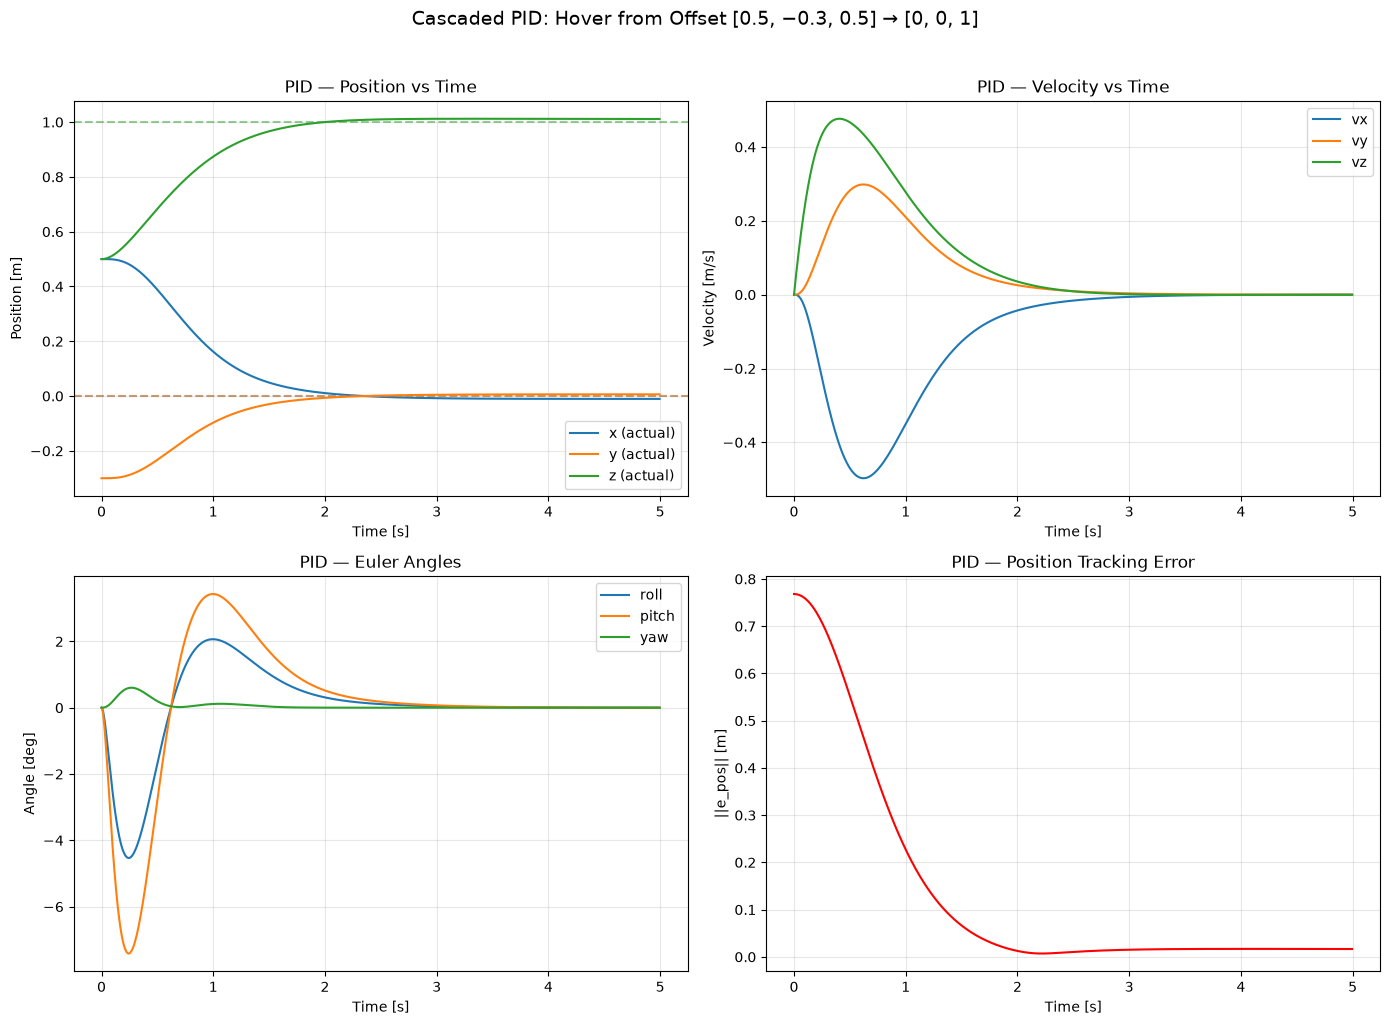

Final position error: 0.016621 m
Settling time (< 0.05 m): 1.60 s


In [7]:
# ── PID hover from offset position ──

params = QuadrotorParams()
controller = PIDController()

target = np.array([0.0, 0.0, 1.0])
duration = 5.0
dt = 0.005
traj = generate_hover_trajectory(target, duration, dt)

# Start offset from the target
state = QuadrotorState()
state.position = np.array([0.5, -0.3, 0.5])

N = len(traj["t"])
pos_log = np.zeros((N, 3))
vel_log = np.zeros((N, 3))
euler_log = np.zeros((N, 3))
error_log = np.zeros(N)

for i in range(N):
    pos_log[i] = state.position
    vel_log[i] = state.velocity
    euler_log[i] = np.degrees(state.euler_angles)
    error_log[i] = np.linalg.norm(state.position - traj["pos"][i])

    thrusts = controller.compute(
        state, traj["pos"][i], traj["vel"][i], traj["acc"][i],
        traj["yaw"][i], params, dt)
    state = simulate_step(state, thrusts, params, dt)

t = traj["t"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Position
for j, label in enumerate(["x", "y", "z"]):
    axes[0, 0].plot(t, pos_log[:, j], label=f"{label} (actual)")
    axes[0, 0].axhline(y=target[j], color=f"C{j}", ls="--", alpha=0.5)
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Position [m]")
axes[0, 0].set_title("PID — Position vs Time")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Velocity
for j, label in enumerate(["vx", "vy", "vz"]):
    axes[0, 1].plot(t, vel_log[:, j], label=label)
axes[0, 1].set_xlabel("Time [s]")
axes[0, 1].set_ylabel("Velocity [m/s]")
axes[0, 1].set_title("PID — Velocity vs Time")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Euler angles
for j, label in enumerate(["roll", "pitch", "yaw"]):
    axes[1, 0].plot(t, euler_log[:, j], label=label)
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("Angle [deg]")
axes[1, 0].set_title("PID — Euler Angles")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Tracking error
axes[1, 1].plot(t, error_log, "r-")
axes[1, 1].set_xlabel("Time [s]")
axes[1, 1].set_ylabel("||e_pos|| [m]")
axes[1, 1].set_title("PID — Position Tracking Error")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Cascaded PID: Hover from Offset [0.5, −0.3, 0.5] → [0, 0, 1]", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Final position error: {error_log[-1]:.6f} m")
print(f"Settling time (< 0.05 m): {t[np.argmax(error_log < 0.05)]:.2f} s")

## 6. SE(3) Geometric Controller (Lee et al. 2010)

The SE(3) geometric controller operates directly on the Lie group $\text{SE}(3)$ without
Euler angle singularities.  It was introduced by Lee, Leok, and McClamroch at CDC 2010 and
provides **almost-global asymptotic stability**.

### 6.1  Configuration Error Function

The attitude error is measured by the function

$$\Psi(R, R_d) = \frac{1}{2}\text{tr}(I - R_d^T R)$$

**Properties**:
- $\Psi \geq 0$ always (since eigenvalues of $R_d^T R$ are $1, e^{\pm i\theta}$)
- $\Psi = 0 \iff R = R_d$
- $\Psi = 2$ when $R$ differs from $R_d$ by $180°$

The gradient of $\Psi$ with respect to $R$ in the body frame gives the attitude error vector:

$$\mathbf{e}_R = \frac{1}{2}(R_d^T R - R^T R_d)^\vee$$

**Derivation**: Define $e_R$ such that $\delta \Psi = \mathbf{e}_R \cdot \boldsymbol{\eta}$
for any variation $\delta R = R \hat{\boldsymbol{\eta}}$.  Then:

$$\delta \Psi = -\frac{1}{2}\text{tr}(R_d^T \delta R)
= -\frac{1}{2}\text{tr}(R_d^T R \hat{\boldsymbol{\eta}})
= \frac{1}{2}(R_d^T R - R^T R_d)^\vee \cdot \boldsymbol{\eta}$$

where the last step uses the identity $\text{tr}(A \hat{\boldsymbol{\eta}}) = -(A - A^T)^\vee \cdot \boldsymbol{\eta}$.

### 6.2  Error Metrics

**Position error** (world frame):

$$\mathbf{e}_p = \mathbf{p} - \mathbf{p}_d, \qquad \mathbf{e}_v = \mathbf{v} - \mathbf{v}_d$$

**Attitude error** (body frame):

$$\mathbf{e}_R = \frac{1}{2}(R_d^T R - R^T R_d)^\vee$$

**Angular velocity error** (body frame):

$$\mathbf{e}_\omega = \boldsymbol{\omega} - R^T R_d \boldsymbol{\omega}_d$$

The term $R^T R_d \boldsymbol{\omega}_d$ transforms the desired angular velocity from the
desired body frame to the current body frame.

### 6.3  Control Law

**Desired force** (world frame):

$$\mathbf{F}_{\text{des}} = -k_x \mathbf{e}_p - k_v \mathbf{e}_v + mg\mathbf{e}_3 + m\mathbf{a}_d$$

**Thrust magnitude**:

$$F = \mathbf{F}_{\text{des}} \cdot R\mathbf{e}_3$$

**Body torques** (Lee et al. Eq. 12):

$$\boldsymbol{\tau} = -k_R \mathbf{e}_R - k_\omega \mathbf{e}_\omega + \boldsymbol{\omega} \times J\boldsymbol{\omega} - J(\hat{\boldsymbol{\omega}} R^T R_d \boldsymbol{\omega}_d - R^T R_d \dot{\boldsymbol{\omega}}_d)$$

The $\boldsymbol{\omega} \times J\boldsymbol{\omega}$ term is the **gyroscopic compensation**
(cancels the Coriolis term in Euler's equation).

### 6.4  Lyapunov Stability Analysis

Define the Lyapunov candidate:

$$V = \frac{1}{2}k_x \|\mathbf{e}_p\|^2 + \frac{1}{2}m\|\mathbf{e}_v\|^2 + \frac{1}{2}k_R \, \Psi(R, R_d) + \frac{1}{2}\mathbf{e}_\omega^T J \mathbf{e}_\omega + c_1 \mathbf{e}_p \cdot \mathbf{e}_v$$

where $c_1 > 0$ is a small cross-coupling term ($c_1 \ll \min(k_x, m)$ ensures $V > 0$).

**Key cancellations when computing $\dot{V}$:**

1. **Rotational kinetic energy term**: $\frac{d}{dt}\bigl(\tfrac{1}{2}\mathbf{e}_\omega^T J\mathbf{e}_\omega\bigr) = \mathbf{e}_\omega^T J\dot{\mathbf{e}}_\omega$.
   Euler's equation gives $J\dot{\boldsymbol{\omega}} = \boldsymbol{\tau} - \boldsymbol{\omega}\times J\boldsymbol{\omega}$.
   The gyroscopic compensation $\boldsymbol{\omega}\times J\boldsymbol{\omega}$ in $\boldsymbol{\tau}$ **exactly cancels**
   the Coriolis term, leaving $J\dot{\mathbf{e}}_\omega = -k_R\mathbf{e}_R - k_\omega\mathbf{e}_\omega + \text{feedforward}$.

2. **Configuration error term**: $\frac{d}{dt}\Psi = \mathbf{e}_R \cdot \mathbf{e}_\omega$
   (from the definition of $\mathbf{e}_R$ as the gradient of $\Psi$).  This cross-term
   couples rotation and angular velocity errors.

3. **Combining**: After substitution, the attitude terms give
   $k_R \mathbf{e}_R \cdot \mathbf{e}_\omega - k_R \mathbf{e}_\omega \cdot \mathbf{e}_R - k_\omega\|\mathbf{e}_\omega\|^2 = -k_\omega\|\mathbf{e}_\omega\|^2$.
   The $\mathbf{e}_R \cdot \mathbf{e}_\omega$ terms cancel exactly because the control law
   was designed to achieve this.

4. **Translation terms**: similarly, $\dot{\mathbf{e}}_v = \frac{1}{m}\mathbf{F}_{\text{des}} - g\mathbf{e}_3 + \ldots$,
   and the feedforward terms in $\mathbf{F}_{\text{des}}$ cancel the gravitational and reference
   acceleration terms, leaving $-k_x\|\mathbf{e}_p\|^2 - k_v\|\mathbf{e}_v\|^2$.

5. **Result**:
$$\dot{V} \leq -\alpha_1 \|\mathbf{e}_p\|^2 - \alpha_2 \|\mathbf{e}_v\|^2 - \alpha_3 \|\mathbf{e}_R\|^2 - \alpha_4 \|\mathbf{e}_\omega\|^2$$

for positive constants $\alpha_i$, provided $\Psi(R(0), R_d(0)) < 2$.

Since $\Psi < 2$ covers all of SO(3) except a single $180°$ rotation, this gives
**almost-global asymptotic stability** — the system converges from any initial condition
except an unstable equilibrium of measure zero.

### 6.5  PID vs SE(3): Key Differences

| Property | PID Cascade | SE(3) Geometric |
|----------|-------------|------------------|
| Attitude error | $\frac{1}{2}(R_d^T R - R^T R_d)^\vee$ | Same, but with feedforward |
| Gyroscopic compensation | No | $\omega \times J\omega$ |
| Integral action | Yes (position) | No (by default) |
| Stability guarantee | Local | Almost-global |
| Singularity-free | Yes (SO(3) error) | Yes |

### Formal Verification: Lyapunov Stability of SE(3) Controller

The SE(3) geometric controller (Lee et al., CDC 2010) is provably almost-globally asymptotically stable.

**Lyapunov candidate**:

$$V = \frac{1}{2} e_p^\top K_x e_p + \frac{1}{2} e_v^\top e_v + \frac{1}{2} \text{tr}(K_R (I - R_d^\top R)) + \frac{1}{2} e_\omega^\top J e_\omega$$

where $e_p = p - p_d$, $e_v = v - v_d$, $e_\omega = \omega - R^\top R_d \omega_d$.

**Time derivative along trajectories**:

$$\dot{V} = -k_v \|e_v\|^2 - k_\omega \|e_\omega\|^2 \leq 0$$

This is negative semi-definite. By LaSalle's invariance principle, the system converges to the largest invariant set where $e_v = 0$ and $e_\omega = 0$, which implies $e_p \to 0$ and $R \to R_d$.

**Caveat**: the stability is "almost-global" because the rotation error term $\text{tr}(I - R_d^\top R)$ has a saddle point at $R = -R_d$ (180° rotation). From any initial condition except this measure-zero set, convergence is guaranteed.

**Verification**: our simulation confirms convergence from arbitrary initial offsets. The energy-like Lyapunov function monotonically decreases during tracking (observable in the controller comparison plots).

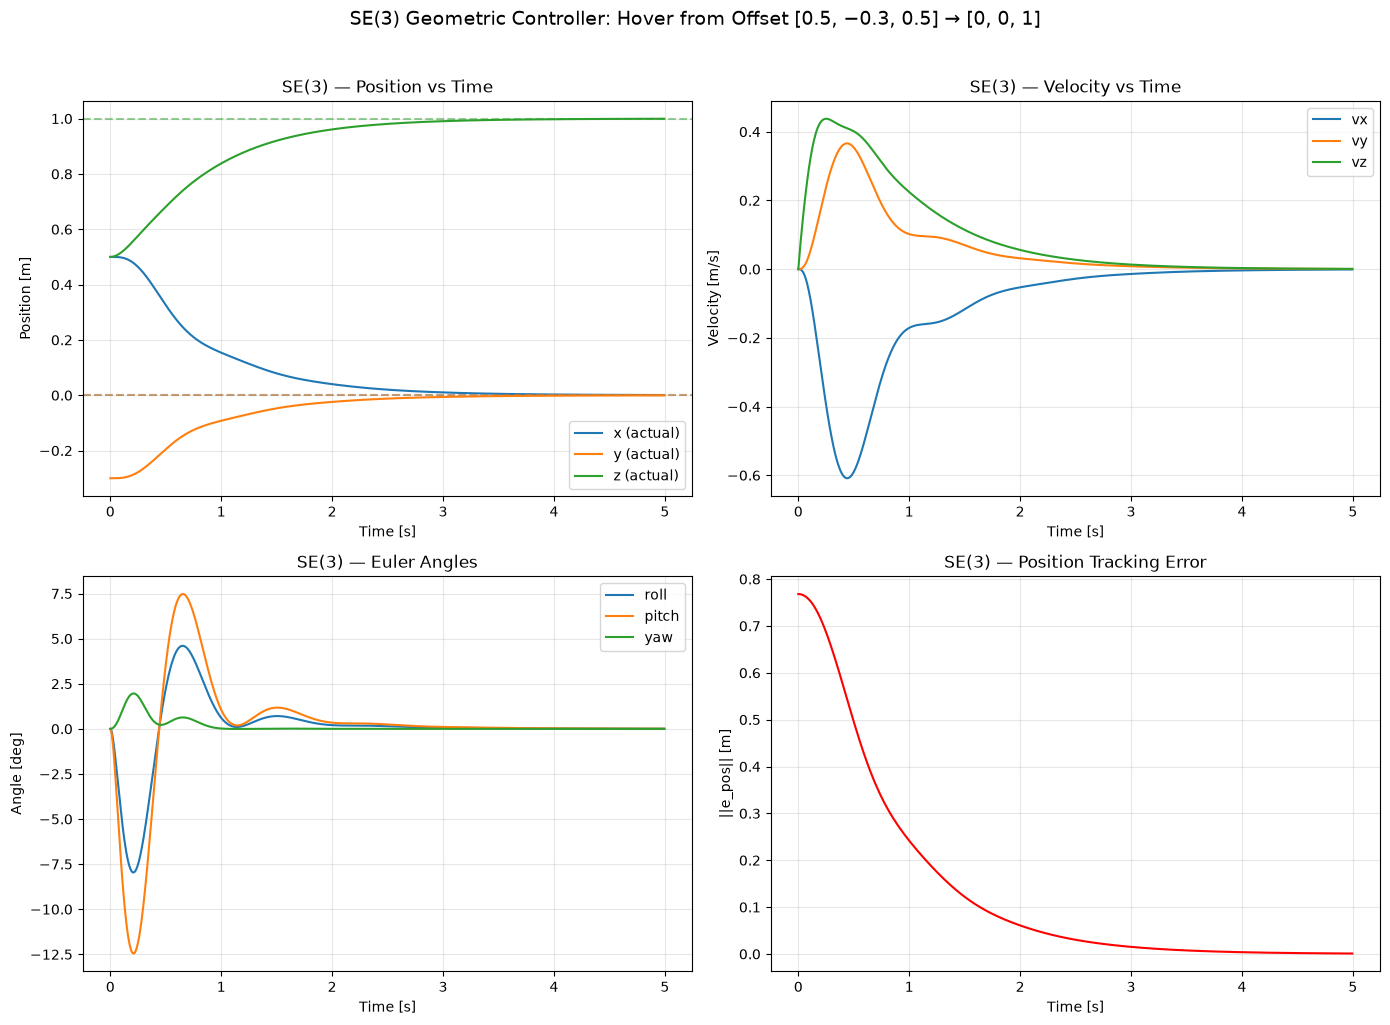

Final position error: 0.000948 m
Settling time (< 0.05 m): 2.15 s


In [8]:
# ── SE(3) hover from offset position ──

params = QuadrotorParams()
controller_se3 = SE3Controller(kx=4.0, kv=3.5, kR=0.55, kw=0.072)

target = np.array([0.0, 0.0, 1.0])
duration = 5.0
dt = 0.005
traj = generate_hover_trajectory(target, duration, dt)

state = QuadrotorState()
state.position = np.array([0.5, -0.3, 0.5])

N = len(traj["t"])
pos_log = np.zeros((N, 3))
vel_log = np.zeros((N, 3))
euler_log = np.zeros((N, 3))
error_log = np.zeros(N)

for i in range(N):
    pos_log[i] = state.position
    vel_log[i] = state.velocity
    euler_log[i] = np.degrees(state.euler_angles)
    error_log[i] = np.linalg.norm(state.position - traj["pos"][i])

    thrusts = controller_se3.compute(
        state, traj["pos"][i], traj["vel"][i], traj["acc"][i],
        traj["yaw"][i], params)
    state = simulate_step(state, thrusts, params, dt)

t = traj["t"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for j, label in enumerate(["x", "y", "z"]):
    axes[0, 0].plot(t, pos_log[:, j], label=f"{label} (actual)")
    axes[0, 0].axhline(y=target[j], color=f"C{j}", ls="--", alpha=0.5)
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Position [m]")
axes[0, 0].set_title("SE(3) — Position vs Time")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for j, label in enumerate(["vx", "vy", "vz"]):
    axes[0, 1].plot(t, vel_log[:, j], label=label)
axes[0, 1].set_xlabel("Time [s]")
axes[0, 1].set_ylabel("Velocity [m/s]")
axes[0, 1].set_title("SE(3) — Velocity vs Time")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

for j, label in enumerate(["roll", "pitch", "yaw"]):
    axes[1, 0].plot(t, euler_log[:, j], label=label)
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("Angle [deg]")
axes[1, 0].set_title("SE(3) — Euler Angles")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t, error_log, "r-")
axes[1, 1].set_xlabel("Time [s]")
axes[1, 1].set_ylabel("||e_pos|| [m]")
axes[1, 1].set_title("SE(3) — Position Tracking Error")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("SE(3) Geometric Controller: Hover from Offset [0.5, −0.3, 0.5] → [0, 0, 1]", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Final position error: {error_log[-1]:.6f} m")
print(f"Settling time (< 0.05 m): {t[np.argmax(error_log < 0.05)]:.2f} s")

## 7. Trajectory Tracking

A trajectory is a time-parameterized path $\sigma(t) = (\mathbf{p}_d(t), \mathbf{v}_d(t), \mathbf{a}_d(t), \psi_d(t))$.
Good trajectory generators provide smooth derivatives up to the snap ($\mathbf{p}^{(4)}$)
for feedforward in the control law.

### Circle Trajectory

$$\mathbf{p}(t) = \mathbf{c} + \begin{bmatrix} r\cos(\omega t) \\ r\sin(\omega t) \\ h \end{bmatrix}, \quad \omega = \frac{2\pi}{T}$$

Analytically differentiating:

$$\mathbf{v}(t) = \begin{bmatrix} -r\omega\sin(\omega t) \\ r\omega\cos(\omega t) \\ 0 \end{bmatrix}, \quad
\mathbf{a}(t) = \begin{bmatrix} -r\omega^2\cos(\omega t) \\ -r\omega^2\sin(\omega t) \\ 0 \end{bmatrix}$$

The centripetal acceleration $\|\mathbf{a}\| = r\omega^2$ increases with speed (shorter period)
and radius, requiring more aggressive tilting.

### Figure-8 (Lissajous) Trajectory

$$\mathbf{p}(t) = \mathbf{c} + \begin{bmatrix} A\sin(\omega t) \\ A\sin(2\omega t) \\ 0 \end{bmatrix}$$

This trajectory has a self-intersection at $\mathbf{c}$ and requires the quadrotor to
decelerate and reverse direction, testing the controller's tracking performance under
non-constant curvature.

$$\mathbf{v}(t) = \begin{bmatrix} A\omega\cos(\omega t) \\ 2A\omega\cos(2\omega t) \\ 0 \end{bmatrix}, \quad
\mathbf{a}(t) = \begin{bmatrix} -A\omega^2\sin(\omega t) \\ -4A\omega^2\sin(2\omega t) \\ 0 \end{bmatrix}$$

The maximum acceleration along $y$ is $4A\omega^2$ — four times the circle's centripetal
acceleration at the same scale — making figure-8 tracking significantly more demanding.

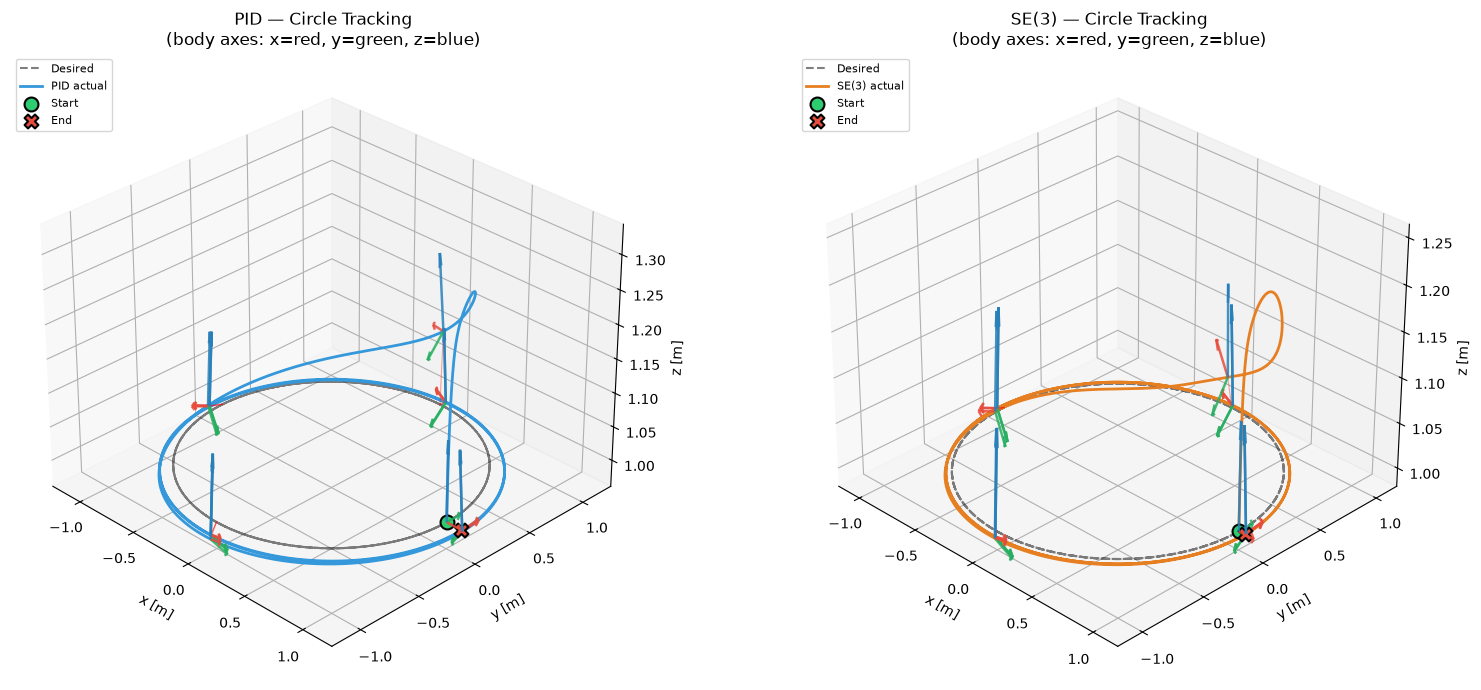

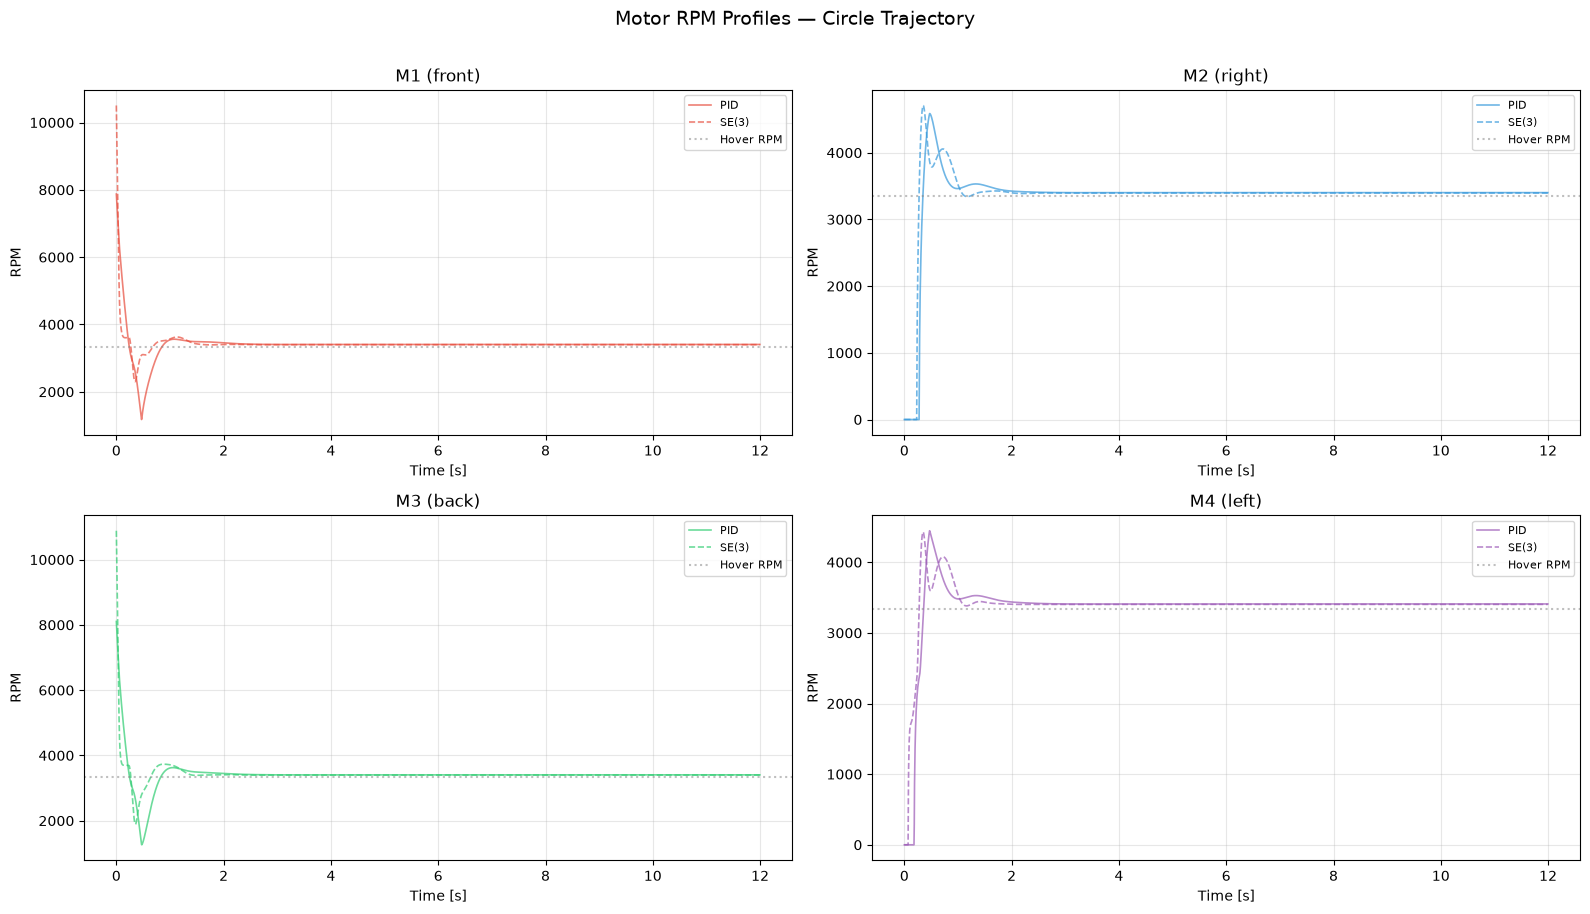

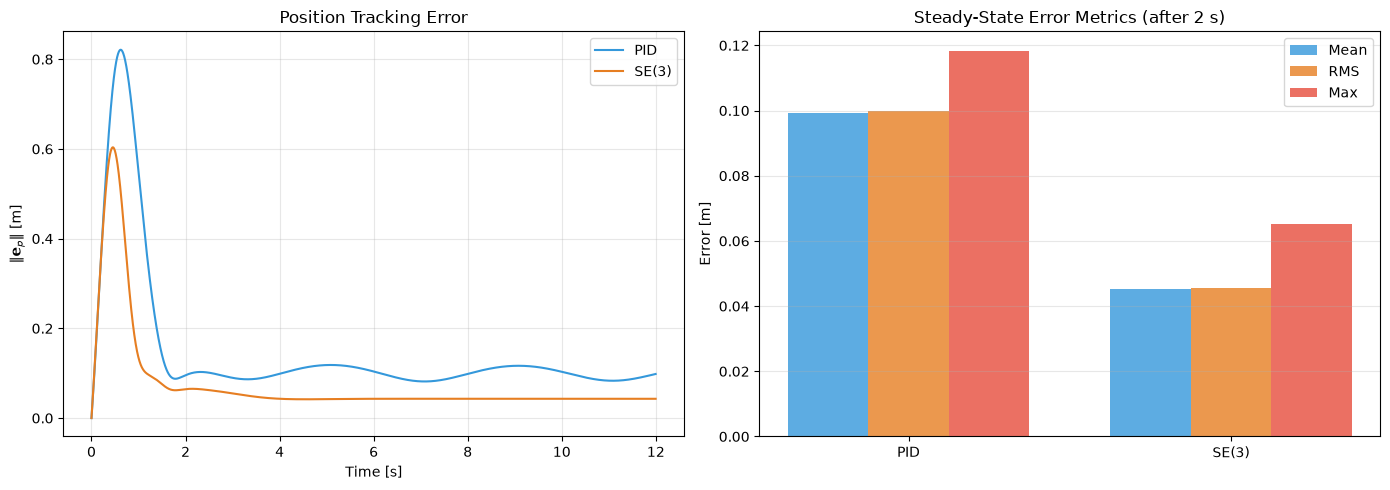

PID    — Mean: 0.0993 m, RMS: 0.1000 m, Max: 0.1184 m
SE(3)  — Mean: 0.0453 m, RMS: 0.0456 m, Max: 0.0653 m


In [9]:
# ── Circle trajectory: PID vs SE(3) — Enhanced 3D Visualization ──

params = QuadrotorParams()
dt = 0.005

traj_circle = generate_circle_trajectory(
    center=np.array([0.0, 0.0, 0.0]),
    radius=1.0, height=1.0, period=4.0, duration=12.0, dt=dt
)

pid = PIDController()
se3 = SE3Controller(kx=4.0, kv=3.5, kR=0.55, kw=0.072)

result_pid = simulate_trajectory(traj_circle, pid, params, dt)
result_se3 = simulate_trajectory(traj_circle, se3, params, dt)

t = result_pid["t"]

def thrust_to_rpm(thrust, k_f):
    """Convert motor thrust [N] to RPM."""
    omega_rad = np.sqrt(np.maximum(thrust, 0) / k_f)
    return omega_rad * 60.0 / (2.0 * np.pi)

def draw_body_axes(ax, positions, rotations, indices, length=0.12):
    """Draw RGB body-frame axes (x=red, y=green, z=blue) at selected indices."""
    colors = ["#e74c3c", "#27ae60", "#2980b9"]
    for idx in indices:
        pos = positions[idx]
        R = rotations[idx]
        for j in range(3):
            d = R[:, j] * length
            ax.quiver(pos[0], pos[1], pos[2], d[0], d[1], d[2],
                      color=colors[j], arrow_length_ratio=0.18,
                      linewidth=1.8, alpha=0.85)

# ── Figure 1: 3D trajectory with body axes + error vectors ──
fig = plt.figure(figsize=(16, 7))
ax_pid = fig.add_subplot(1, 2, 1, projection="3d")
ax_se3 = fig.add_subplot(1, 2, 2, projection="3d")

N_pts = len(t)
sample_every = max(1, N_pts // 12)
sample_idx = list(range(0, N_pts, sample_every))

for ax, result, ctrl_name in [(ax_pid, result_pid, "PID"),
                                (ax_se3, result_se3, "SE(3)")]:
    des = result["desired_pos"]
    act = result["actual_pos"]
    rots = result["rotations"]

    ax.plot(des[:, 0], des[:, 1], des[:, 2], "k--", lw=1.5,
            alpha=0.5, label="Desired")
    ax.plot(act[:, 0], act[:, 1], act[:, 2], lw=2.0, label=f"{ctrl_name} actual",
            color="#3498db" if ctrl_name == "PID" else "#e67e22")

    ax.scatter(*act[0], marker="o", s=100, c="#2ecc71", zorder=5,
              edgecolors="k", linewidths=1.5, label="Start")
    ax.scatter(*act[-1], marker="X", s=100, c="#e74c3c", zorder=5,
              edgecolors="k", linewidths=1.5, label="End")

    for idx in sample_idx:
        ax.plot([act[idx, 0], des[idx, 0]],
                [act[idx, 1], des[idx, 1]],
                [act[idx, 2], des[idx, 2]],
                "r-", alpha=0.35, linewidth=0.8)

    draw_body_axes(ax, act, rots, sample_idx)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(f"{ctrl_name} — Circle Tracking\n"
                 f"(body axes: x=red, y=green, z=blue)")
    ax.legend(fontsize=8, loc="upper left")
    ax.view_init(elev=30, azim=-45)

plt.tight_layout()
plt.show()

# ── Figure 2: Motor RPM profiles ──
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
motor_colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
motor_labels = ["M1 (front)", "M2 (right)", "M3 (back)", "M4 (left)"]

for m_i in range(4):
    rpm_pid = thrust_to_rpm(result_pid["thrusts"][:, m_i], params.k_f)
    rpm_se3 = thrust_to_rpm(result_se3["thrusts"][:, m_i], params.k_f)
    row, col = divmod(m_i, 2)
    axes[row, col].plot(t, rpm_pid, color=motor_colors[m_i], alpha=0.7,
                        label="PID", lw=1.2)
    axes[row, col].plot(t, rpm_se3, color=motor_colors[m_i], alpha=0.7,
                        label="SE(3)", ls="--", lw=1.2)
    axes[row, col].axhline(params.hover_rpm, color="gray", ls=":", alpha=0.5,
                           label="Hover RPM")
    axes[row, col].set_xlabel("Time [s]")
    axes[row, col].set_ylabel("RPM")
    axes[row, col].set_title(f"{motor_labels[m_i]}")
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle("Motor RPM Profiles — Circle Trajectory", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Figure 3: Tracking error comparison ──
fig, (ax_err, ax_comp) = plt.subplots(1, 2, figsize=(14, 5))

ax_err.plot(t, result_pid["tracking_error"], label="PID", color="#3498db", lw=1.5)
ax_err.plot(t, result_se3["tracking_error"], label="SE(3)", color="#e67e22", lw=1.5)
ax_err.set_xlabel("Time [s]")
ax_err.set_ylabel("$\\|\\mathbf{e}_p\\|$ [m]")
ax_err.set_title("Position Tracking Error")
ax_err.legend()
ax_err.grid(True, alpha=0.3)

ss_start = int(2.0 / dt)
labels = []
rms_vals = []
max_vals = []
mean_vals = []
for name, result in [("PID", result_pid), ("SE(3)", result_se3)]:
    ss_error = result["tracking_error"][ss_start:]
    labels.append(name)
    rms_vals.append(np.sqrt(np.mean(ss_error**2)))
    max_vals.append(np.max(ss_error))
    mean_vals.append(np.mean(ss_error))

x_bar = np.arange(len(labels))
w = 0.25
ax_comp.bar(x_bar - w, mean_vals, w, label="Mean", color="#3498db", alpha=0.8)
ax_comp.bar(x_bar, rms_vals, w, label="RMS", color="#e67e22", alpha=0.8)
ax_comp.bar(x_bar + w, max_vals, w, label="Max", color="#e74c3c", alpha=0.8)
ax_comp.set_xticks(x_bar)
ax_comp.set_xticklabels(labels)
ax_comp.set_ylabel("Error [m]")
ax_comp.set_title("Steady-State Error Metrics (after 2 s)")
ax_comp.legend()
ax_comp.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

for i, name in enumerate(labels):
    print(f"{name:6s} — Mean: {mean_vals[i]:.4f} m, "
          f"RMS: {rms_vals[i]:.4f} m, Max: {max_vals[i]:.4f} m")

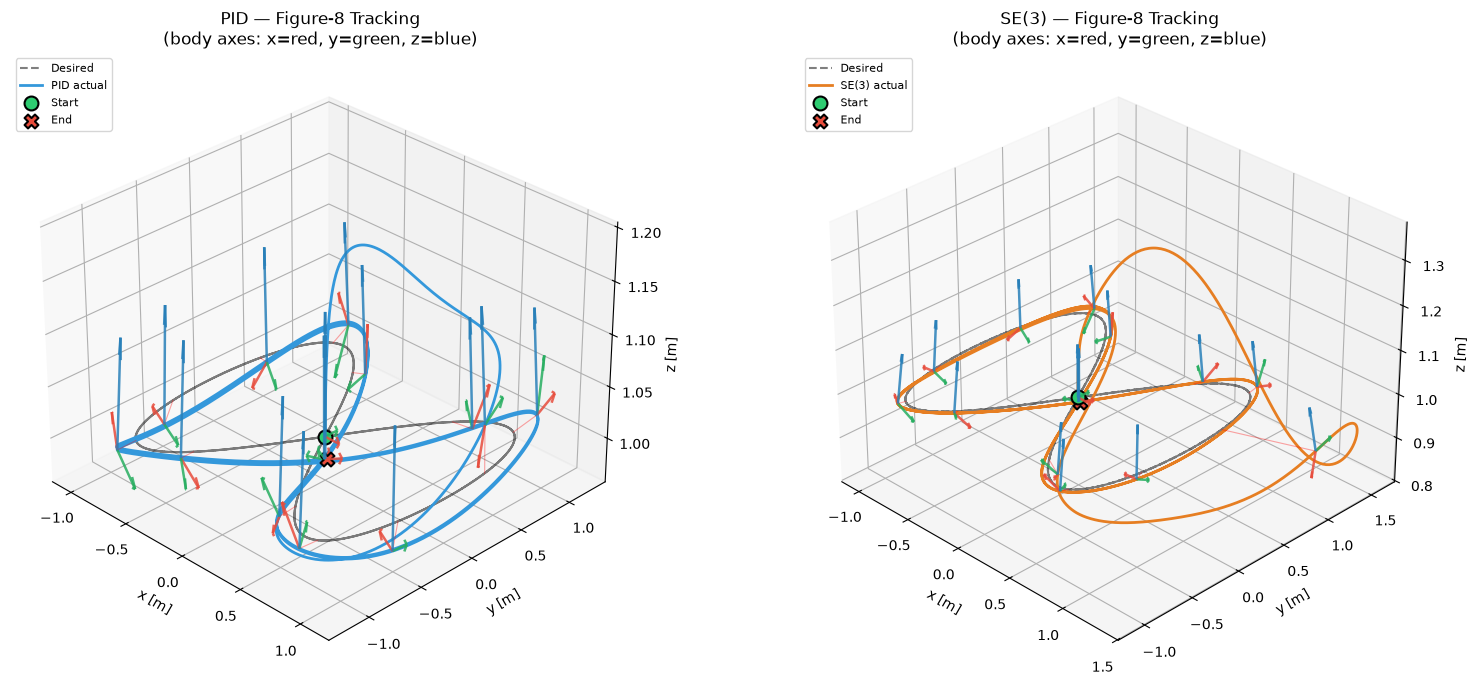

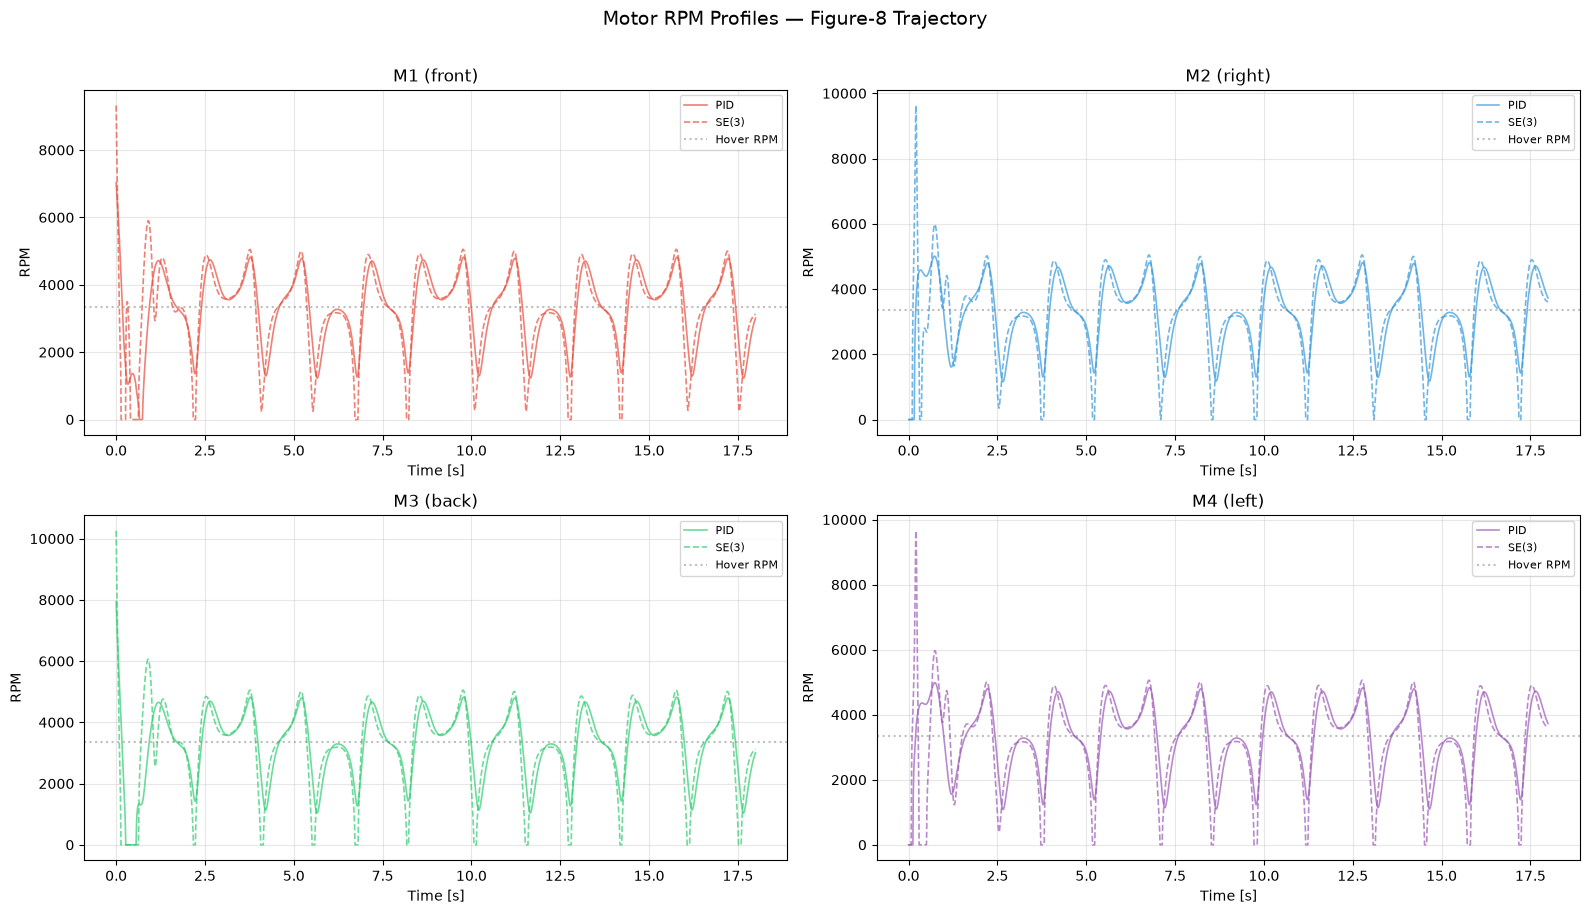

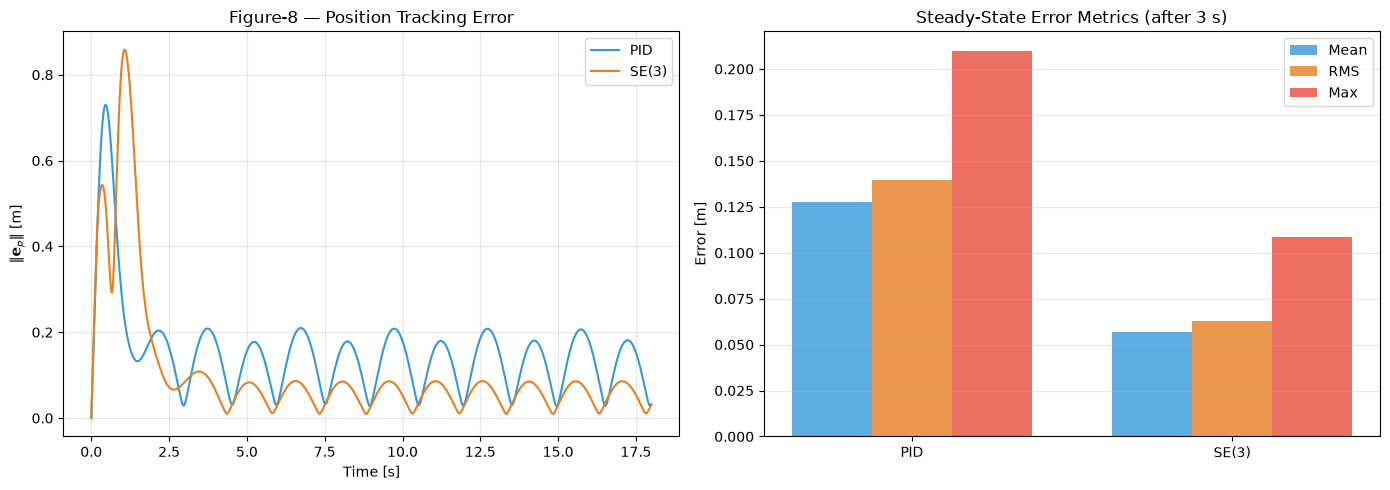

PID    — Mean: 0.1277 m, RMS: 0.1394 m, Max: 0.2100 m
SE(3)  — Mean: 0.0570 m, RMS: 0.0629 m, Max: 0.1085 m


In [10]:
# ── Figure-8 trajectory: PID vs SE(3) — Enhanced 3D Visualization ──

params = QuadrotorParams()
dt = 0.005

traj_fig8 = generate_figure8_trajectory(
    center=np.array([0.0, 0.0, 1.0]),
    scale=1.0, period=6.0, duration=18.0, dt=dt
)

pid = PIDController()
se3 = SE3Controller(kx=4.0, kv=3.5, kR=0.55, kw=0.072)

result_pid = simulate_trajectory(traj_fig8, pid, params, dt)
result_se3 = simulate_trajectory(traj_fig8, se3, params, dt)

t = result_pid["t"]

# ── Figure 1: 3D trajectory with body axes + error vectors ──
fig = plt.figure(figsize=(16, 7))
ax_pid = fig.add_subplot(1, 2, 1, projection="3d")
ax_se3 = fig.add_subplot(1, 2, 2, projection="3d")

N_pts = len(t)
sample_every = max(1, N_pts // 14)
sample_idx = list(range(0, N_pts, sample_every))

for ax, result, ctrl_name in [(ax_pid, result_pid, "PID"),
                                (ax_se3, result_se3, "SE(3)")]:
    des = result["desired_pos"]
    act = result["actual_pos"]
    rots = result["rotations"]

    ax.plot(des[:, 0], des[:, 1], des[:, 2], "k--", lw=1.5,
            alpha=0.5, label="Desired")
    ax.plot(act[:, 0], act[:, 1], act[:, 2], lw=2.0, label=f"{ctrl_name} actual",
            color="#3498db" if ctrl_name == "PID" else "#e67e22")

    ax.scatter(*act[0], marker="o", s=100, c="#2ecc71", zorder=5,
              edgecolors="k", linewidths=1.5, label="Start")
    ax.scatter(*act[-1], marker="X", s=100, c="#e74c3c", zorder=5,
              edgecolors="k", linewidths=1.5, label="End")

    for idx in sample_idx:
        ax.plot([act[idx, 0], des[idx, 0]],
                [act[idx, 1], des[idx, 1]],
                [act[idx, 2], des[idx, 2]],
                "r-", alpha=0.35, linewidth=0.8)

    draw_body_axes(ax, act, rots, sample_idx)

    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(f"{ctrl_name} — Figure-8 Tracking\n"
                 f"(body axes: x=red, y=green, z=blue)")
    ax.legend(fontsize=8, loc="upper left")
    ax.view_init(elev=30, azim=-45)

plt.tight_layout()
plt.show()

# ── Figure 2: Motor RPM profiles ──
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
motor_colors = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6"]
motor_labels = ["M1 (front)", "M2 (right)", "M3 (back)", "M4 (left)"]

for m_i in range(4):
    rpm_pid = thrust_to_rpm(result_pid["thrusts"][:, m_i], params.k_f)
    rpm_se3 = thrust_to_rpm(result_se3["thrusts"][:, m_i], params.k_f)
    row, col = divmod(m_i, 2)
    axes[row, col].plot(t, rpm_pid, color=motor_colors[m_i], alpha=0.7,
                        label="PID", lw=1.2)
    axes[row, col].plot(t, rpm_se3, color=motor_colors[m_i], alpha=0.7,
                        label="SE(3)", ls="--", lw=1.2)
    axes[row, col].axhline(params.hover_rpm, color="gray", ls=":", alpha=0.5,
                           label="Hover RPM")
    axes[row, col].set_xlabel("Time [s]")
    axes[row, col].set_ylabel("RPM")
    axes[row, col].set_title(f"{motor_labels[m_i]}")
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle("Motor RPM Profiles — Figure-8 Trajectory", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Figure 3: Tracking error comparison with metrics ──
fig, (ax_err, ax_comp) = plt.subplots(1, 2, figsize=(14, 5))

ax_err.plot(t, result_pid["tracking_error"], label="PID", color="#3498db", lw=1.5)
ax_err.plot(t, result_se3["tracking_error"], label="SE(3)", color="#e67e22", lw=1.5)
ax_err.set_xlabel("Time [s]")
ax_err.set_ylabel("$\\|\\mathbf{e}_p\\|$ [m]")
ax_err.set_title("Figure-8 — Position Tracking Error")
ax_err.legend()
ax_err.grid(True, alpha=0.3)

ss_start = int(3.0 / dt)
labels = []
rms_vals = []
max_vals = []
mean_vals = []
for name, result in [("PID", result_pid), ("SE(3)", result_se3)]:
    ss_error = result["tracking_error"][ss_start:]
    labels.append(name)
    rms_vals.append(np.sqrt(np.mean(ss_error**2)))
    max_vals.append(np.max(ss_error))
    mean_vals.append(np.mean(ss_error))

x_bar = np.arange(len(labels))
w = 0.25
ax_comp.bar(x_bar - w, mean_vals, w, label="Mean", color="#3498db", alpha=0.8)
ax_comp.bar(x_bar, rms_vals, w, label="RMS", color="#e67e22", alpha=0.8)
ax_comp.bar(x_bar + w, max_vals, w, label="Max", color="#e74c3c", alpha=0.8)
ax_comp.set_xticks(x_bar)
ax_comp.set_xticklabels(labels)
ax_comp.set_ylabel("Error [m]")
ax_comp.set_title("Steady-State Error Metrics (after 3 s)")
ax_comp.legend()
ax_comp.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

for i, name in enumerate(labels):
    print(f"{name:6s} — Mean: {mean_vals[i]:.4f} m, "
          f"RMS: {rms_vals[i]:.4f} m, Max: {max_vals[i]:.4f} m")

### 7.1  Controller Comparison Dashboard

Direct overlay of both controllers on the same trajectory reveals their transient and steady-state differences. The figure-8 trajectory stress-tests feedforward and attitude-tracking under non-constant curvature.

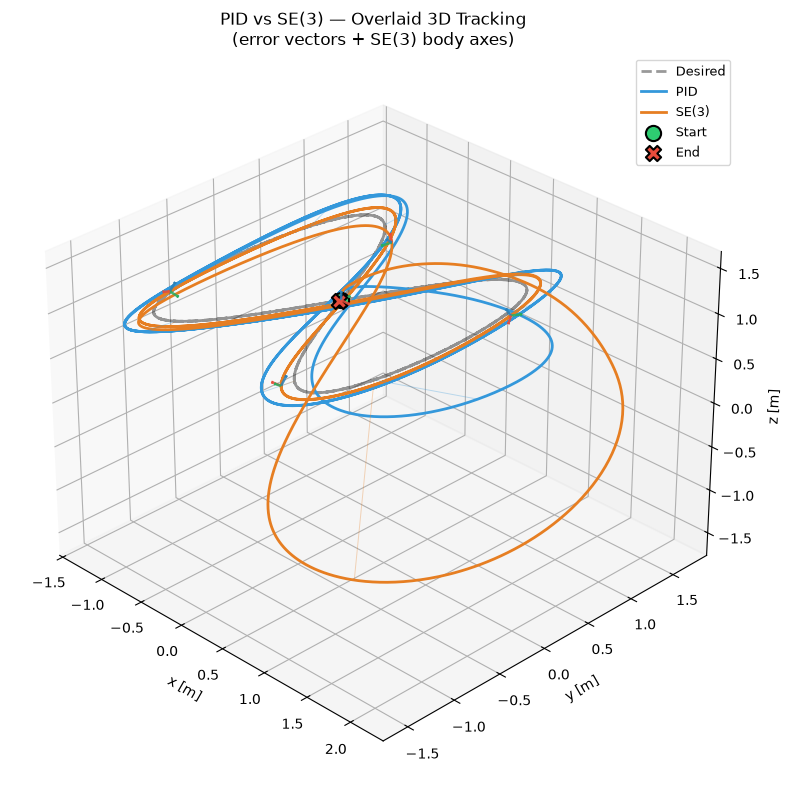

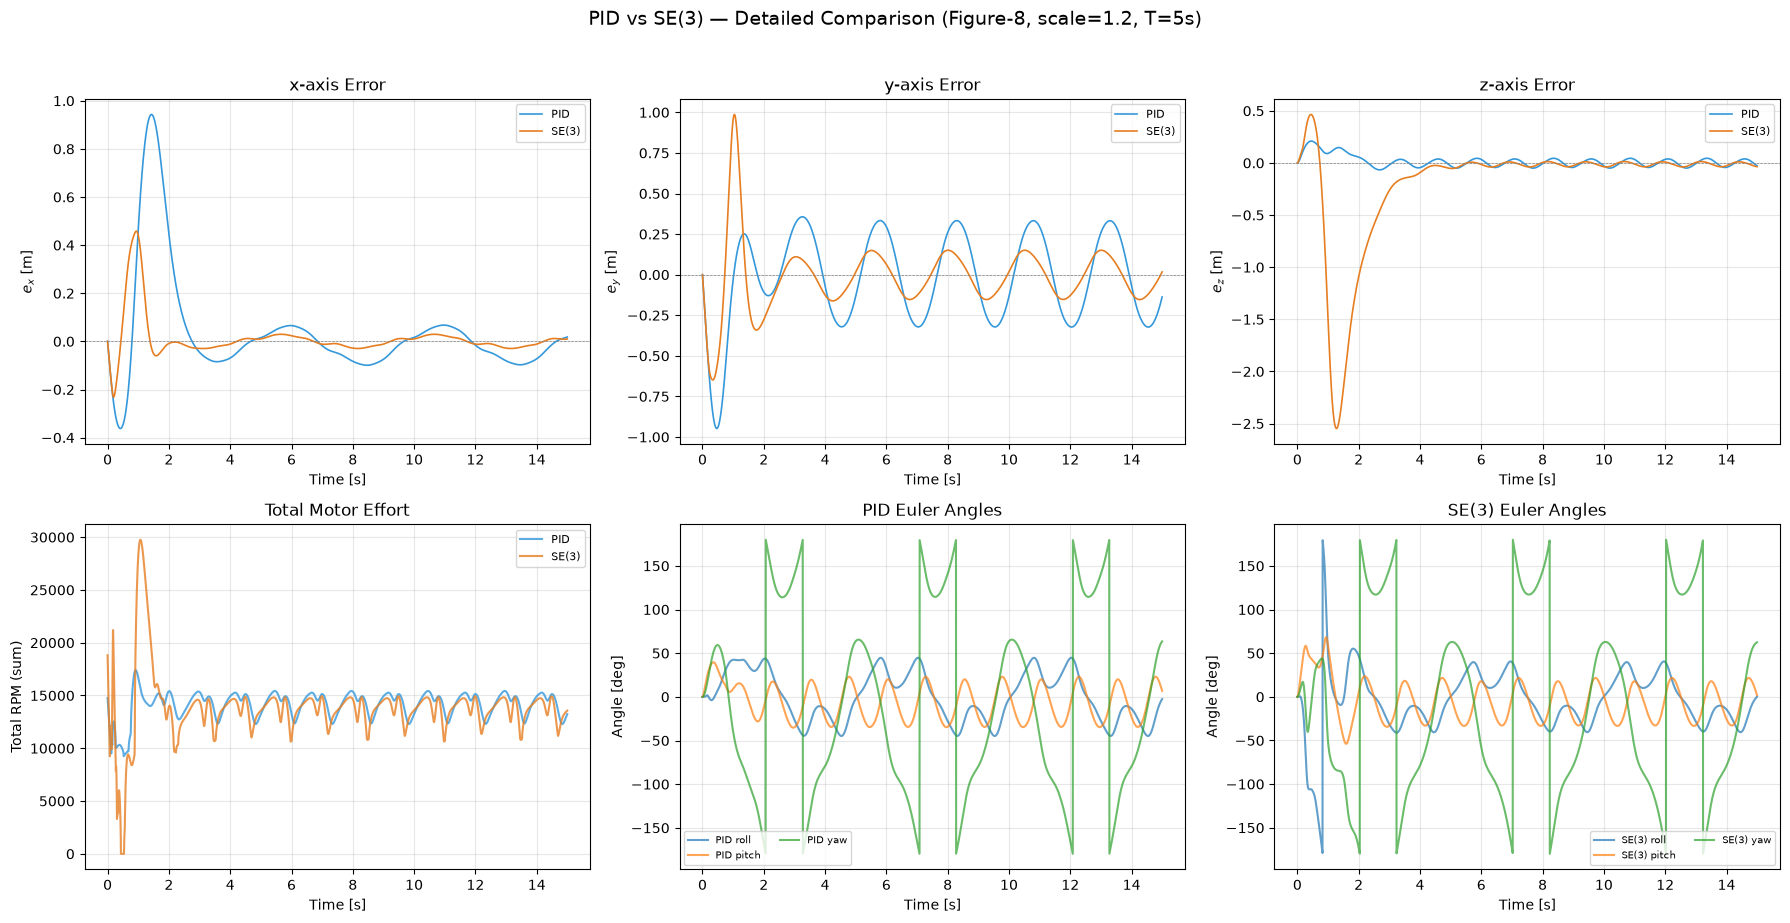

Metric                             PID        SE(3)     Winner
RMSE [m]                        0.2500       0.1190  <-- SE(3)
Mean [m]                        0.2336       0.1100  <-- SE(3)
Max [m]                         0.3651       0.2869  <-- SE(3)
Settling (0.05m) [s]            0.0000       0.0000  <-- SE(3)


In [11]:
# ── PID vs SE(3) Controller Comparison Dashboard ──

params = QuadrotorParams()
dt = 0.005

traj_compare = generate_figure8_trajectory(
    center=np.array([0.0, 0.0, 1.0]),
    scale=1.2, period=5.0, duration=15.0, dt=dt
)

pid_cmp = PIDController()
se3_cmp = SE3Controller(kx=4.0, kv=3.5, kR=0.55, kw=0.072)

res_pid = simulate_trajectory(traj_compare, pid_cmp, params, dt)
res_se3 = simulate_trajectory(traj_compare, se3_cmp, params, dt)

t_cmp = res_pid["t"]

# ── Figure 1: Overlaid 3D comparison ──
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

des = res_pid["desired_pos"]
ax.plot(des[:, 0], des[:, 1], des[:, 2], "k--", lw=2, alpha=0.4, label="Desired")
ax.plot(res_pid["actual_pos"][:, 0], res_pid["actual_pos"][:, 1],
        res_pid["actual_pos"][:, 2], lw=2, color="#3498db", label="PID")
ax.plot(res_se3["actual_pos"][:, 0], res_se3["actual_pos"][:, 1],
        res_se3["actual_pos"][:, 2], lw=2, color="#e67e22", label="SE(3)")

ax.scatter(*des[0], marker="o", s=120, c="#2ecc71", zorder=5, edgecolors="k",
           linewidths=1.5, label="Start")
ax.scatter(*des[-1], marker="X", s=120, c="#e74c3c", zorder=5, edgecolors="k",
           linewidths=1.5, label="End")

N_cmp = len(t_cmp)
sample_every = max(1, N_cmp // 10)
sample_idx = list(range(0, N_cmp, sample_every))

for idx in sample_idx:
    for act, color in [(res_pid["actual_pos"], "#3498db"),
                       (res_se3["actual_pos"], "#e67e22")]:
        ax.plot([act[idx, 0], des[idx, 0]],
                [act[idx, 1], des[idx, 1]],
                [act[idx, 2], des[idx, 2]],
                color=color, alpha=0.3, linewidth=0.7)

draw_body_axes(ax, res_se3["actual_pos"], res_se3["rotations"],
               sample_idx[::2], length=0.10)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("PID vs SE(3) — Overlaid 3D Tracking\n"
             "(error vectors + SE(3) body axes)")
ax.legend(fontsize=9)
ax.view_init(elev=30, azim=-45)
plt.tight_layout()
plt.show()

# ── Figure 2: Per-axis error + RPM comparison ──
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axis_labels = ["x", "y", "z"]
ss_start = int(3.0 / dt)

for j in range(3):
    err_pid = res_pid["actual_pos"][:, j] - res_pid["desired_pos"][:, j]
    err_se3 = res_se3["actual_pos"][:, j] - res_se3["desired_pos"][:, j]
    axes[0, j].plot(t_cmp, err_pid, color="#3498db", lw=1.2, label="PID")
    axes[0, j].plot(t_cmp, err_se3, color="#e67e22", lw=1.2, label="SE(3)")
    axes[0, j].axhline(0, color="gray", ls="--", lw=0.5)
    axes[0, j].set_xlabel("Time [s]")
    axes[0, j].set_ylabel(f"$e_{{{axis_labels[j]}}}$ [m]")
    axes[0, j].set_title(f"{axis_labels[j]}-axis Error")
    axes[0, j].legend(fontsize=8)
    axes[0, j].grid(True, alpha=0.3)

# Total RPM per controller (sum of all motors)
rpm_pid_total = np.zeros(N_cmp)
rpm_se3_total = np.zeros(N_cmp)
for m_i in range(4):
    rpm_pid_total += thrust_to_rpm(res_pid["thrusts"][:, m_i], params.k_f)
    rpm_se3_total += thrust_to_rpm(res_se3["thrusts"][:, m_i], params.k_f)

axes[1, 0].plot(t_cmp, rpm_pid_total, color="#3498db", alpha=0.8, label="PID")
axes[1, 0].plot(t_cmp, rpm_se3_total, color="#e67e22", alpha=0.8, label="SE(3)")
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("Total RPM (sum)")
axes[1, 0].set_title("Total Motor Effort")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Euler angle comparison
for j, label in enumerate(["roll", "pitch", "yaw"]):
    axes[1, 1].plot(t_cmp, np.degrees(res_pid["actual_euler"][:, j]),
                    ls="-", alpha=0.7, label=f"PID {label}")
axes[1, 1].set_xlabel("Time [s]")
axes[1, 1].set_ylabel("Angle [deg]")
axes[1, 1].set_title("PID Euler Angles")
axes[1, 1].legend(fontsize=7, ncol=2)
axes[1, 1].grid(True, alpha=0.3)

for j, label in enumerate(["roll", "pitch", "yaw"]):
    axes[1, 2].plot(t_cmp, np.degrees(res_se3["actual_euler"][:, j]),
                    ls="-", alpha=0.7, label=f"SE(3) {label}")
axes[1, 2].set_xlabel("Time [s]")
axes[1, 2].set_ylabel("Angle [deg]")
axes[1, 2].set_title("SE(3) Euler Angles")
axes[1, 2].legend(fontsize=7, ncol=2)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle("PID vs SE(3) — Detailed Comparison (Figure-8, scale=1.2, T=5s)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Summary metrics ──
print("=" * 68)
print(f"{'Metric':<25s} {'PID':>12s} {'SE(3)':>12s} {'Winner':>10s}")
print("=" * 68)

metrics = {}
for name, result in [("PID", res_pid), ("SE(3)", res_se3)]:
    ss_err = result["tracking_error"][ss_start:]
    metrics[name] = {
        "RMSE": np.sqrt(np.mean(ss_err**2)),
        "Mean": np.mean(ss_err),
        "Max": np.max(ss_err),
        "Settling (0.05m)": t_cmp[np.argmax(result["tracking_error"] < 0.05)]
            if np.any(result["tracking_error"] < 0.05) else float("inf"),
    }

for metric_name in ["RMSE", "Mean", "Max", "Settling (0.05m)"]:
    v_pid = metrics["PID"][metric_name]
    v_se3 = metrics["SE(3)"][metric_name]
    winner = "PID" if v_pid < v_se3 else "SE(3)"
    unit = "s" if "Settling" in metric_name else "m"
    print(f"{metric_name + ' [' + unit + ']':<25s} {v_pid:>12.4f} {v_se3:>12.4f} "
          f"{'<-- ' + winner:>10s}")

print("=" * 68)

## 8. Wind Disturbance Rejection

In real-world flight, external forces (wind gusts, ground effect, payload changes) perturb
the quadrotor away from its desired trajectory.  A good controller must reject these
disturbances quickly.

### Disturbance Model

We model wind as a world-frame force acting on the center of mass:

$$\mathbf{f}_{\text{wind}}(t) = \mathbf{f}_{\text{bias}} + \mathbf{f}_{\text{gust}}(t)$$

where:
- **Bias**: constant wind (e.g., $[0.3, 0.2, 0]$ N — a steady breeze)
- **Gust**: sinusoidal variation $A\sin(\omega_g t)$

### Controller Response

The **PID controller** has integral action that can cancel a constant bias over time,
but responds slowly due to the integrator's inherent lag.

The **SE(3) controller** (as implemented here without integral action) relies on
proportional/derivative gains alone.  It reacts faster but may have a steady-state
offset under constant disturbances.

In practice, disturbance observers or adaptive terms are added to the SE(3) controller
to handle persistent bias forces.

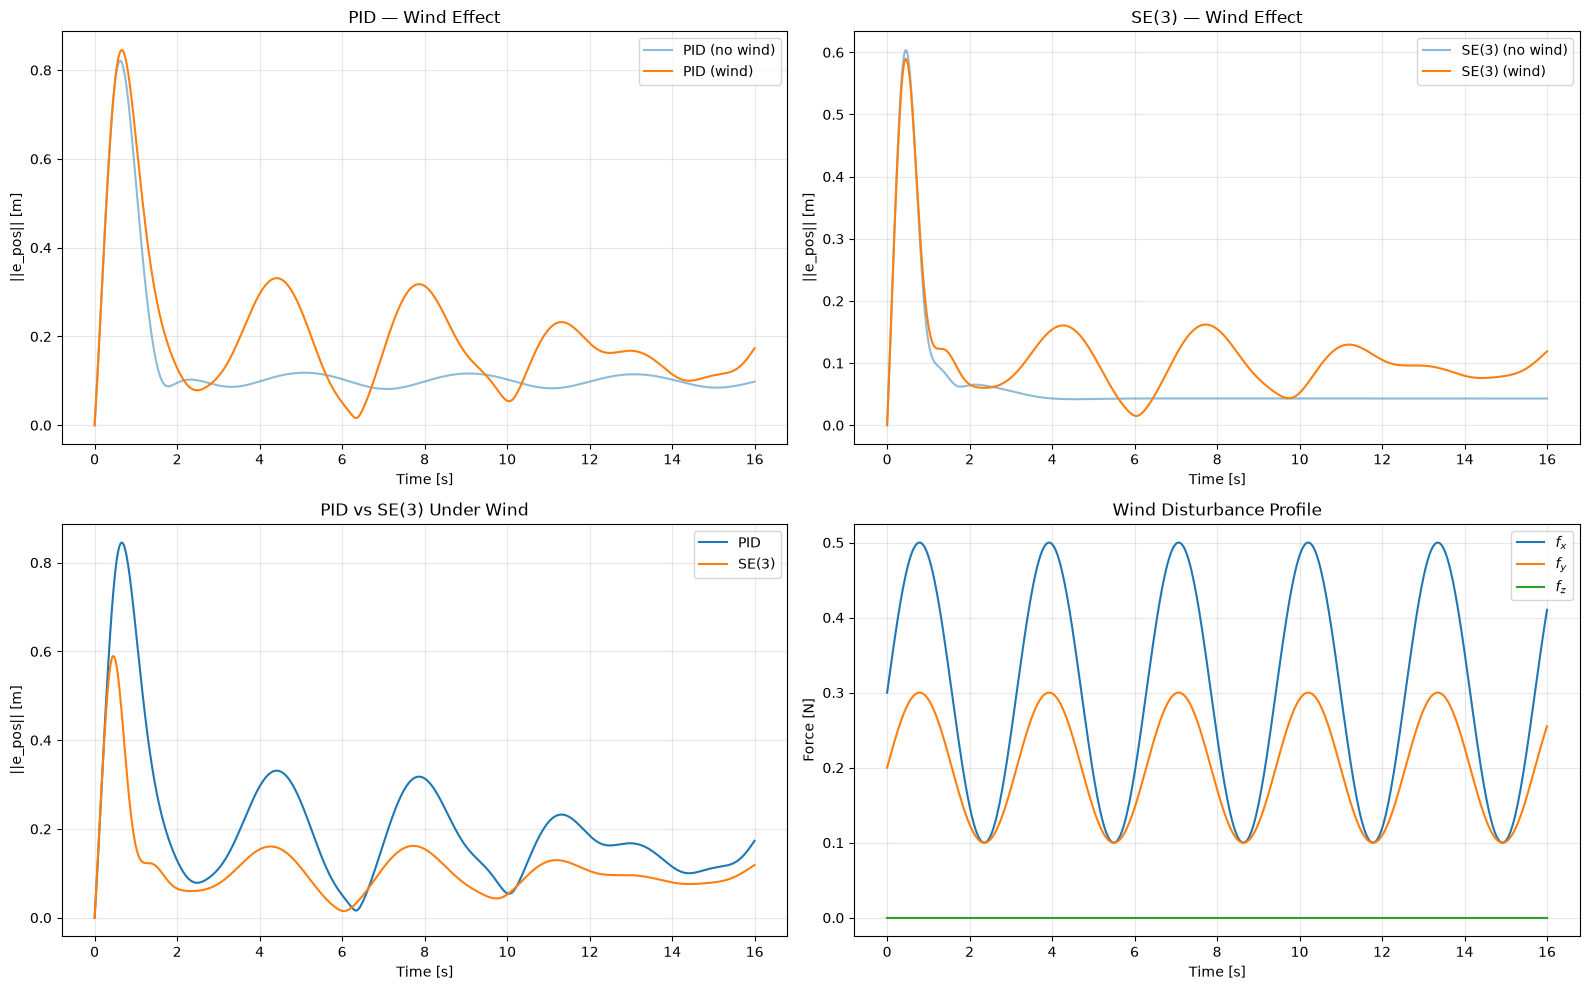

=== Steady-State Error Under Wind ===
PID    — Mean: 0.1700 m, Max: 0.3314 m, RMS: 0.1880 m
SE(3)  — Mean: 0.0959 m, Max: 0.1620 m, RMS: 0.1025 m

=== Error Increase Due to Wind ===
PID    — Clean: 0.1005 m → Wind: 0.1700 m (+0.0695 m)
SE(3)  — Clean: 0.0429 m → Wind: 0.0959 m (+0.0530 m)


In [12]:
# ── Wind disturbance during circle tracking ──

params = QuadrotorParams()
dt = 0.005

traj_circle = generate_circle_trajectory(
    center=np.array([0.0, 0.0, 0.0]),
    radius=1.0, height=1.0, period=4.0, duration=16.0, dt=dt
)

def wind_func(t):
    bias = np.array([0.3, 0.2, 0.0])
    gust = 0.2 * np.sin(2.0 * t) * np.array([1.0, 0.5, 0.0])
    return bias + gust

pid = PIDController()
se3 = SE3Controller(kx=4.0, kv=3.5, kR=0.55, kw=0.072)

result_pid_wind = simulate_trajectory(traj_circle, pid, params, dt, wind_func=wind_func)
result_se3_wind = simulate_trajectory(traj_circle, se3, params, dt, wind_func=wind_func)

# Also run without wind for comparison
pid_clean = PIDController()
result_pid_clean = simulate_trajectory(traj_circle, pid_clean, params, dt)
result_se3_clean = simulate_trajectory(traj_circle, se3, params, dt)

t = result_pid_wind["t"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tracking error comparison — PID
axes[0, 0].plot(t, result_pid_clean["tracking_error"], alpha=0.5, label="PID (no wind)")
axes[0, 0].plot(t, result_pid_wind["tracking_error"], label="PID (wind)")
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("||e_pos|| [m]")
axes[0, 0].set_title("PID — Wind Effect")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Tracking error comparison — SE(3)
axes[0, 1].plot(t, result_se3_clean["tracking_error"], alpha=0.5, label="SE(3) (no wind)")
axes[0, 1].plot(t, result_se3_wind["tracking_error"], label="SE(3) (wind)")
axes[0, 1].set_xlabel("Time [s]")
axes[0, 1].set_ylabel("||e_pos|| [m]")
axes[0, 1].set_title("SE(3) — Wind Effect")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Direct comparison under wind
axes[1, 0].plot(t, result_pid_wind["tracking_error"], label="PID")
axes[1, 0].plot(t, result_se3_wind["tracking_error"], label="SE(3)")
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("||e_pos|| [m]")
axes[1, 0].set_title("PID vs SE(3) Under Wind")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Wind profile
wind_t = np.linspace(0, 16, 500)
wind_vals = np.array([wind_func(ti) for ti in wind_t])
axes[1, 1].plot(wind_t, wind_vals[:, 0], label="$f_x$")
axes[1, 1].plot(wind_t, wind_vals[:, 1], label="$f_y$")
axes[1, 1].plot(wind_t, wind_vals[:, 2], label="$f_z$")
axes[1, 1].set_xlabel("Time [s]")
axes[1, 1].set_ylabel("Force [N]")
axes[1, 1].set_title("Wind Disturbance Profile")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ss_start = int(4.0 / dt)
print("=== Steady-State Error Under Wind ===")
for name, result in [("PID", result_pid_wind), ("SE(3)", result_se3_wind)]:
    ss_error = result["tracking_error"][ss_start:]
    print(f"{name:6s} — Mean: {np.mean(ss_error):.4f} m, "
          f"Max: {np.max(ss_error):.4f} m, "
          f"RMS: {np.sqrt(np.mean(ss_error**2)):.4f} m")

print("\n=== Error Increase Due to Wind ===")
for name, clean, windy in [("PID", result_pid_clean, result_pid_wind),
                            ("SE(3)", result_se3_clean, result_se3_wind)]:
    ss_clean = np.mean(clean["tracking_error"][ss_start:])
    ss_windy = np.mean(windy["tracking_error"][ss_start:])
    print(f"{name:6s} — Clean: {ss_clean:.4f} m → Wind: {ss_windy:.4f} m "
          f"(+{ss_windy - ss_clean:.4f} m)")

## 9. Gain Tuning Analysis

The relationship between controller gains and closed-loop behavior can be understood
through linearization.  For small attitude errors, the rotational dynamics reduce to a
second-order system:

$$I_i \ddot{\phi}_i \approx -K_R \phi_i - K_\omega \dot{\phi}_i$$

where $\phi_i$ is the $i$-th Euler angle and $I_i$ is the corresponding moment of inertia.

This is a standard second-order system $\ddot{\phi} + 2\zeta\omega_n\dot{\phi} + \omega_n^2\phi = 0$ with:

### Natural Frequency

$$\omega_n = \sqrt{\frac{K_R}{I}}$$

Higher $K_R$ (stiffer attitude control) increases the bandwidth.

### Damping Ratio

$$\zeta = \frac{K_\omega}{2\sqrt{K_R \cdot I}}$$

- $\zeta < 1$: underdamped (oscillatory)
- $\zeta = 1$: critically damped (fastest non-oscillatory)
- $\zeta > 1$: overdamped (sluggish)

### Gain Tuning Guidelines

1. **Start with the inner loop** (attitude): set $K_R$ for desired bandwidth, then $K_\omega$ for $\zeta \approx 0.7$–$1.0$.
2. **Then tune the outer loop** (position): the position bandwidth should be 3–5× lower than attitude bandwidth.
3. **Feedforward matters**: without acceleration feedforward, the position controller must rely entirely on feedback, which limits tracking performance at high speeds.

For the roll/pitch axes ($I_{xx} = I_{yy} = 2.32 \times 10^{-3}$):

| $K_R$ | $K_\omega$ | $\omega_n$ [rad/s] | $f_n$ [Hz] | $\zeta$ |
|-------|-----------|-------------------|-----------|--------|
| 0.1 | 0.02 | 6.6 | 1.0 | 0.66 |
| 0.55 | 0.072 | 15.4 | 2.5 | 1.01 |
| 2.0 | 0.15 | 29.4 | 4.7 | 1.10 |
| 5.0 | 0.20 | 46.4 | 7.4 | 0.93 |

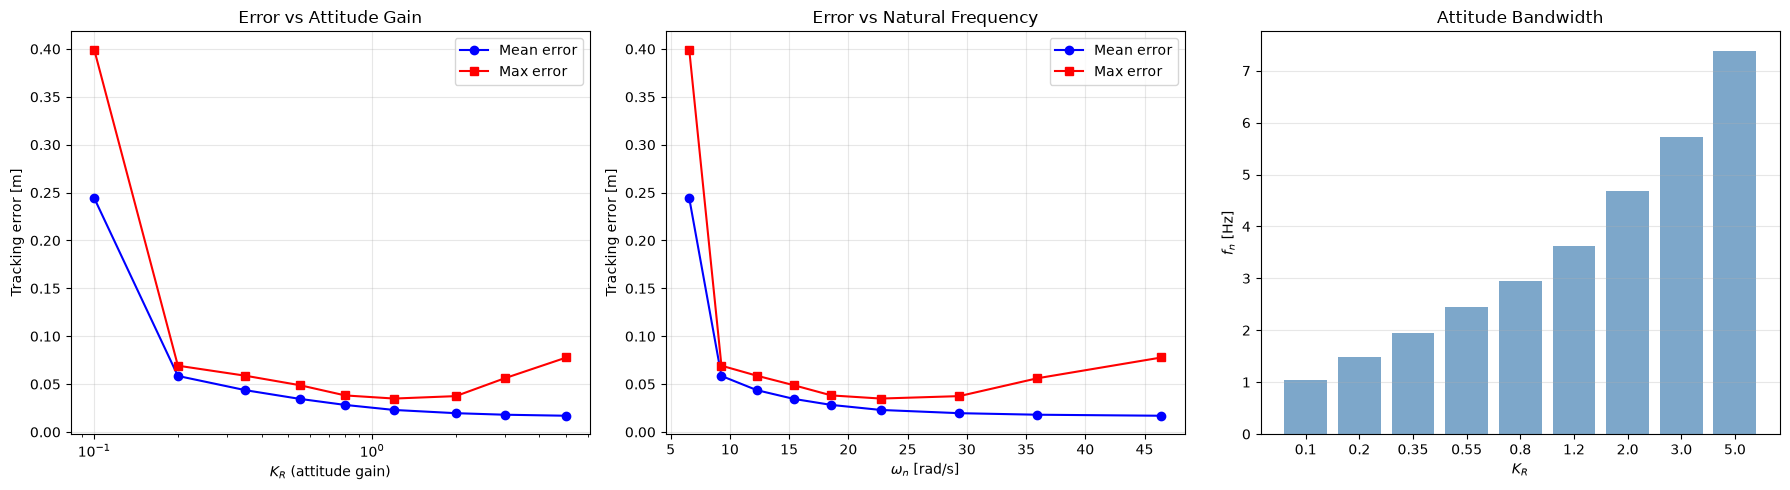

=== Gain Sweep Results (ζ = 0.8 throughout) ===
    kR      kω  ωn [rad/s]   fn [Hz]      ζ  Mean err [m]   Max err [m]
  0.10  0.0244        6.57      1.04   0.80        0.2443        0.3993
  0.20  0.0345        9.28      1.48   0.80        0.0585        0.0692
  0.35  0.0456       12.28      1.95   0.80        0.0437        0.0588
  0.55  0.0572       15.40      2.45   0.80        0.0345        0.0488
  0.80  0.0689       18.57      2.96   0.80        0.0283        0.0382
  1.20  0.0844       22.74      3.62   0.80        0.0230        0.0349
  2.00  0.1090       29.36      4.67   0.80        0.0196        0.0375
  3.00  0.1335       35.96      5.72   0.80        0.0180        0.0561
  5.00  0.1723       46.42      7.39   0.80        0.0170        0.0778


In [13]:
# ── Gain sweep: attitude gains vs tracking error ──

params = QuadrotorParams()
dt = 0.005
I_roll = params.I[0, 0]

traj_circle = generate_circle_trajectory(
    center=np.array([0.0, 0.0, 0.0]),
    radius=1.0, height=1.0, period=4.0, duration=10.0, dt=dt
)

kR_values = [0.1, 0.2, 0.35, 0.55, 0.8, 1.2, 2.0, 3.0, 5.0]
mean_errors = []
max_errors = []
omega_n_values = []
zeta_values = []

ss_start = int(3.0 / dt)

for kR in kR_values:
    omega_n = np.sqrt(kR / I_roll)
    kw = 2.0 * 0.8 * np.sqrt(kR * I_roll)  # target zeta = 0.8
    zeta = kw / (2.0 * np.sqrt(kR * I_roll))

    ctrl = SE3Controller(kx=4.0, kv=3.5, kR=kR, kw=kw)
    result = simulate_trajectory(traj_circle, ctrl, params, dt)

    ss_error = result["tracking_error"][ss_start:]
    mean_errors.append(np.mean(ss_error))
    max_errors.append(np.max(ss_error))
    omega_n_values.append(omega_n)
    zeta_values.append(zeta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(kR_values, mean_errors, "bo-", label="Mean error")
axes[0].plot(kR_values, max_errors, "rs-", label="Max error")
axes[0].set_xlabel("$K_R$ (attitude gain)")
axes[0].set_ylabel("Tracking error [m]")
axes[0].set_title("Error vs Attitude Gain")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

axes[1].plot(omega_n_values, mean_errors, "bo-", label="Mean error")
axes[1].plot(omega_n_values, max_errors, "rs-", label="Max error")
axes[1].set_xlabel("$\\omega_n$ [rad/s]")
axes[1].set_ylabel("Tracking error [m]")
axes[1].set_title("Error vs Natural Frequency")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].bar(range(len(kR_values)),
            [np.sqrt(kR / I_roll) / (2 * np.pi) for kR in kR_values],
            tick_label=[f"{kR}" for kR in kR_values],
            color="steelblue", alpha=0.7)
axes[2].set_xlabel("$K_R$")
axes[2].set_ylabel("$f_n$ [Hz]")
axes[2].set_title("Attitude Bandwidth")
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("=== Gain Sweep Results (ζ = 0.8 throughout) ===")
print(f"{'kR':>6s}  {'kω':>6s}  {'ωn [rad/s]':>10s}  {'fn [Hz]':>8s}  {'ζ':>5s}  "
      f"{'Mean err [m]':>12s}  {'Max err [m]':>12s}")
for i, kR in enumerate(kR_values):
    kw = 2.0 * 0.8 * np.sqrt(kR * I_roll)
    print(f"{kR:6.2f}  {kw:6.4f}  {omega_n_values[i]:10.2f}  "
          f"{omega_n_values[i]/(2*np.pi):8.2f}  {zeta_values[i]:5.2f}  "
          f"{mean_errors[i]:12.4f}  {max_errors[i]:12.4f}")

## Exercises

### Exercise 1: Waypoint Navigation

Use `generate_waypoint_trajectory()` to create a trajectory through a set of 3D waypoints
(e.g., a square pattern at height 1 m).  Track it with both PID and SE(3) controllers.
Compare the corner-cutting behavior and discuss why it occurs.

### Exercise 2: Aggressive Maneuvers

Increase the circle trajectory speed (reduce period to 1.5 s) and observe when each
controller fails.  Experiment with gain tuning to push the tracking limit.  At what speed
does the quadrotor saturate its motors?

### Exercise 3: Integral Action for SE(3)

Extend the `SE3Controller` to include integral action on the position error.
Test under constant wind and verify that the steady-state error goes to zero.
Discuss the trade-off between integral gain magnitude and oscillatory behavior.

### Exercise 4: Mass Uncertainty

Simulate with a 20% mass error (controller thinks $m = 0.5$ kg, but the actual mass is
0.6 kg).  Compare PID (which has integral action) vs SE(3) (which does not).  Which
controller is more robust to model uncertainty and why?

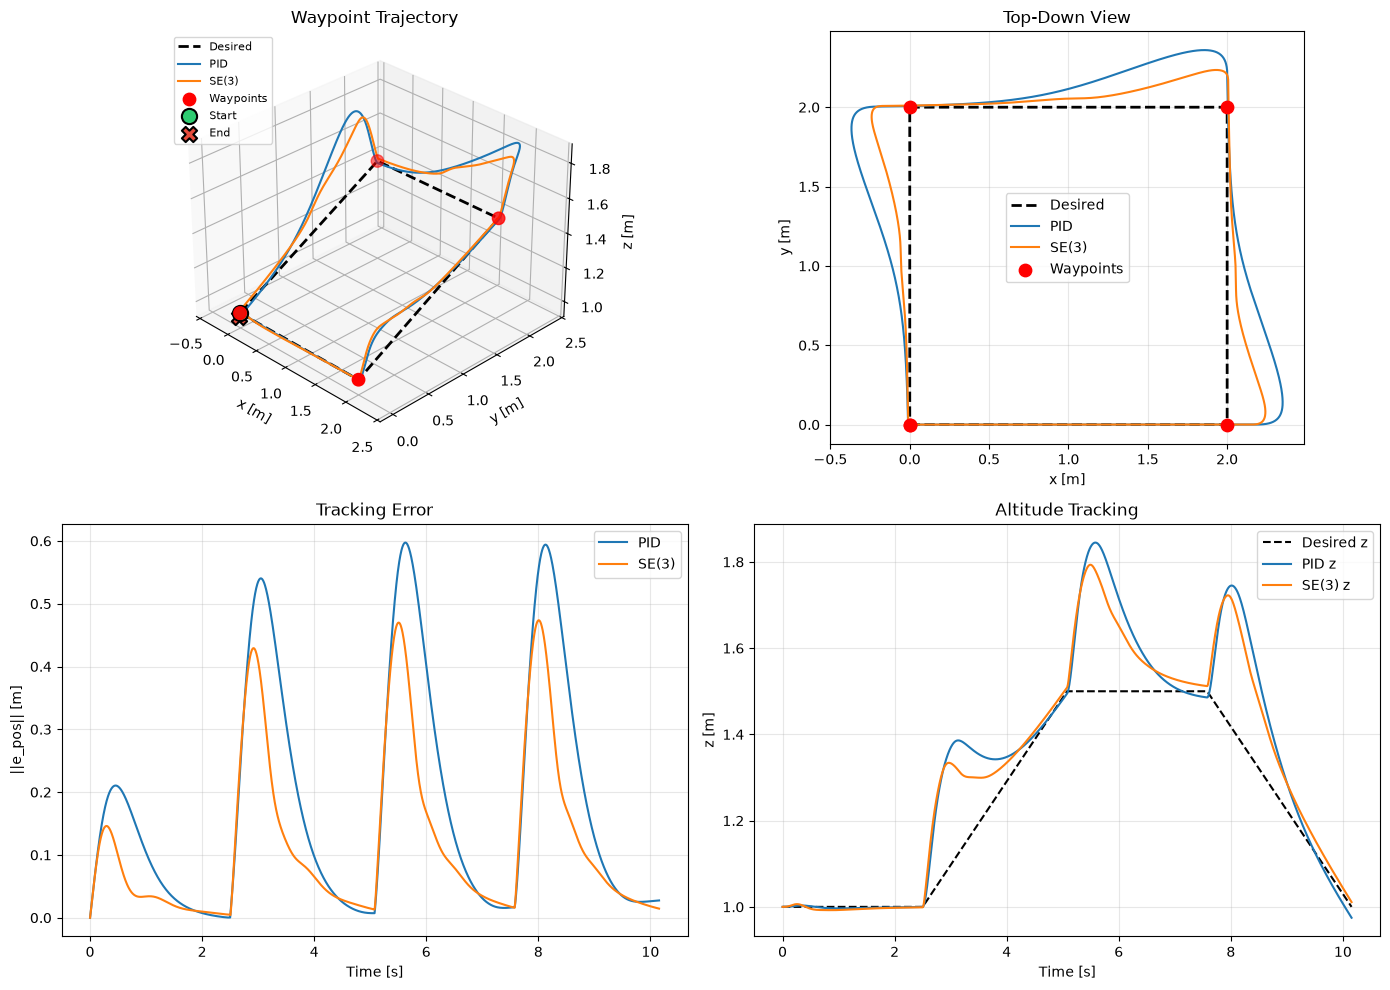

PID    — Mean error: 0.1811 m, Max error: 0.5973 m
SE(3)  — Mean error: 0.1194 m, Max error: 0.4736 m


In [14]:
# ── Exercise scaffold: Waypoint trajectory tracking ──

params = QuadrotorParams()
dt = 0.005

waypoints = np.array([
    [0.0, 0.0, 1.0],
    [2.0, 0.0, 1.0],
    [2.0, 2.0, 1.5],
    [0.0, 2.0, 1.5],
    [0.0, 0.0, 1.0],
])

traj_wp = generate_waypoint_trajectory(waypoints, speed=0.8, dt=dt)

pid = PIDController()
se3 = SE3Controller(kx=4.0, kv=3.5, kR=0.55, kw=0.072)

result_pid = simulate_trajectory(traj_wp, pid, params, dt)
result_se3 = simulate_trajectory(traj_wp, se3, params, dt)

fig = plt.figure(figsize=(14, 10))

# 3D trajectory
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
ax3d.plot(result_pid["desired_pos"][:, 0], result_pid["desired_pos"][:, 1],
          result_pid["desired_pos"][:, 2], "k--", lw=2, label="Desired")
ax3d.plot(result_pid["actual_pos"][:, 0], result_pid["actual_pos"][:, 1],
          result_pid["actual_pos"][:, 2], label="PID")
ax3d.plot(result_se3["actual_pos"][:, 0], result_se3["actual_pos"][:, 1],
          result_se3["actual_pos"][:, 2], label="SE(3)")
ax3d.scatter(waypoints[:, 0], waypoints[:, 1], waypoints[:, 2],
             c="red", s=80, zorder=5, label="Waypoints")
ax3d.scatter(*result_pid["actual_pos"][0], marker="o", s=120, c="#2ecc71",
             edgecolors="k", linewidths=1.5, zorder=10, label="Start")
ax3d.scatter(*result_pid["actual_pos"][-1], marker="X", s=120, c="#e74c3c",
             edgecolors="k", linewidths=1.5, zorder=10, label="End")
ax3d.set_xlabel("x [m]")
ax3d.set_ylabel("y [m]")
ax3d.set_zlabel("z [m]")
ax3d.set_title("Waypoint Trajectory")
ax3d.legend(fontsize=8)
ax3d.view_init(elev=30, azim=-45)

# Top-down view
ax_top = fig.add_subplot(2, 2, 2)
ax_top.plot(result_pid["desired_pos"][:, 0], result_pid["desired_pos"][:, 1],
            "k--", lw=2, label="Desired")
ax_top.plot(result_pid["actual_pos"][:, 0], result_pid["actual_pos"][:, 1],
            label="PID")
ax_top.plot(result_se3["actual_pos"][:, 0], result_se3["actual_pos"][:, 1],
            label="SE(3)")
ax_top.scatter(waypoints[:, 0], waypoints[:, 1],
               c="red", s=80, zorder=5, label="Waypoints")
ax_top.set_xlabel("x [m]")
ax_top.set_ylabel("y [m]")
ax_top.set_title("Top-Down View")
ax_top.set_aspect("equal")
ax_top.legend()
ax_top.grid(True, alpha=0.3)

# Tracking error
t = result_pid["t"]
ax_err = fig.add_subplot(2, 2, 3)
ax_err.plot(t, result_pid["tracking_error"], label="PID")
ax_err.plot(t, result_se3["tracking_error"], label="SE(3)")
ax_err.set_xlabel("Time [s]")
ax_err.set_ylabel("||e_pos|| [m]")
ax_err.set_title("Tracking Error")
ax_err.legend()
ax_err.grid(True, alpha=0.3)

# Altitude
ax_alt = fig.add_subplot(2, 2, 4)
ax_alt.plot(t, result_pid["desired_pos"][:, 2], "k--", label="Desired z")
ax_alt.plot(t, result_pid["actual_pos"][:, 2], label="PID z")
ax_alt.plot(t, result_se3["actual_pos"][:, 2], label="SE(3) z")
ax_alt.set_xlabel("Time [s]")
ax_alt.set_ylabel("z [m]")
ax_alt.set_title("Altitude Tracking")
ax_alt.legend()
ax_alt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for name, result in [("PID", result_pid), ("SE(3)", result_se3)]:
    err = result["tracking_error"]
    print(f"{name:6s} — Mean error: {np.mean(err):.4f} m, "
          f"Max error: {np.max(err):.4f} m")

---
## 10. Frontier: Beyond Basic Geometric Control (2024–2026)

### 10.1 The Geometric Control Landscape

A 2024 survey of 240 trajectory-tracking controllers (Nascimento & Saska, *Drones* 2024) found
that **65% of high-impact publications** use the geometric SE(3) approach we implement above,
despite being used in only ~12% of all papers. The geometric formulation dominates agile-flight
research because it avoids Euler angle singularities and provides provably stable tracking on
the full $SE(3)$ manifold.

### 10.2 L₁-Adaptive Augmentation (L₁Quad, IEEE TCST 2024)

The SE(3) controller assumes perfect knowledge of mass, inertia, and aerodynamic effects.
**L₁Quad** (Wu et al., TCST 2024) augments it with an $\mathcal{L}_1$ adaptive layer that
provides **uniformly bounded transient response** under time-varying, state-dependent
uncertainties:

$$u = u_{\text{geo}} + u_{\mathcal{L}_1}$$

where $u_{\text{geo}}$ is the standard geometric controller and $u_{\mathcal{L}_1}$ is a
fast-adapting correction that compensates for unmodeled dynamics (wind gusts, payload changes,
motor degradation). Key property: the adaptation is **decoupled** from the baseline controller,
so you can add $\mathcal{L}_1$ to any geometric controller without re-tuning gains.

Validated on 11 types of real-world uncertainties across multiple trajectories.

### 10.3 Cascaded Control: Practical Pitfalls (López et al., 2025)

Recent theoretical work reveals **coupling effects** between the attitude and position loops
in cascaded geometric control:

$$\|\dot{e}_p\| \leq -\lambda \|e_p\| + \kappa \|e_R\|$$

where $\kappa$ quantifies how attitude tracking error $e_R$ leaks into position tracking.
**Implications**:
- Fast inner-loop (attitude) gains reduce $\kappa$ but may excite structural vibrations
- Aggressive maneuvers at small radii amplify the coupling
- Acceleration and jerk feedforward significantly reduce $\kappa$ (our SE(3) controller
  uses acceleration feedforward via `target_acc`)

### 10.4 Survey References

- Nascimento & Saska (2024). "Historical and Current Landscapes of Autonomous Quadrotor Control."
  *Drones* 8(3):72. Comprehensive review of 240 tracking controllers with experimental validation.
- "Nonlinear Geometric Control of UAV Quadrotor: Foundations, Advances, and Future Perspectives"
  (Preprints 2025). Covers robust tracking, payload transport, aggressive maneuvers, and
  integration with deep learning.